# Autonomous activated amplification - Simulations

## Model schematic

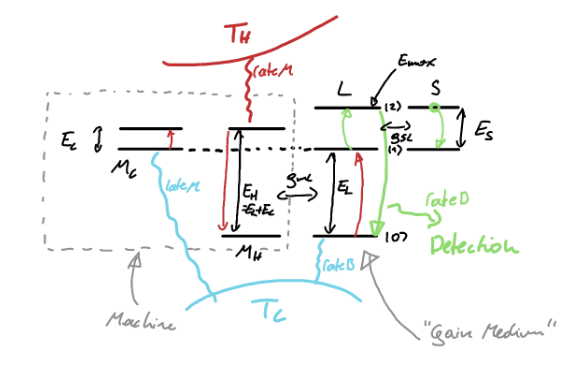

Some of the relations:

+ Cold machine qubit energy: $E_C=f E_L$ where $f$ can in principle be any positiv real number.
+ $E_H=E_L+E_C=E_L(1+f)$
+ $E_L=E_\mathrm{max}-E_S$
+ $T_V=\dfrac{E_H}{\tfrac{E_H}{T_H}-\tfrac{E_C}{T_C}}$

We fix $E_\mathrm{max}$, $E_S$, $\mathrm{rate}_B$

This makes the parameters that are still free:
$T_C$, $T_V$, $g_{ml}$, $g_{sl}$, $\mathrm{rate}_M$, $\mathrm{rate}_D$, $f$

## Initialisation of libraries and parameters

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolor
from Functions import *
from Hamiltonians import *
from FigOMerit_functions import *
from scipy.stats.qmc import *
import os

# Enable LaTeX rendering for text
plt.rcParams.update({
    "text.usetex": True,         # Use LaTeX for text rendering
    "font.family": "serif",      # Use a serif font
    "font.serif": ["Computer Modern"],  # Use Computer Modern for a classic LaTeX look
    "axes.titlesize": 14,        # Title font size
    "axes.labelsize": 12,        # Label font size
    "xtick.labelsize": 10,       # X-tick font size
    "ytick.labelsize": 10,       # Y-tick font size
})


def chop(expr, *, max=10**(-10)):
    return [i if i > max else 0 for i in expr]


In [3]:
#######################################################################
### Variables Most relevant for below (the ones that we investigate)###
#######################################################################

parameters = {
    # General parameters
    "d_l": 3,         # Ladder dimension
    "e_max": 1,       # Energy of most excited level of ladder (threshold energy)
    "e_s": 0.1,       # System (photon) energy
    "TH": 10,         # Hot bath temperature
    "TC": 0.1,        # Cold bath temperature

    # Interaction strengths
    "g_sl": 1,        # System-ladder interaction strength
    "g_ml": 1,        # Machine-ladder interaction strength

    # Energies
    "e_C": 1,       # Cold bath gap
    "e_C_factor": 0.3, # Factor for cold bath gap calculation
    "t_f": 3000,       # Final time
    "t_steps": 3000,   # Number of timesteps

    # Jump rates
    "rateM": 1,       # Dissipator rate machine-baths
    "rateD": 1,       # Dissipation rate detection channel
    "rateB": 1,     # Thermalizing rate ladder-bath
    "Tb": 0.1,        # Ladder bath temperature
    "Td": 0.1,        # Detection channel temperature

    # Constant k
    "k": 1,

    "Tb_indep_flag": False,  # Flag for independent ladder bath temperature,
    "Td_indep_flag": False,  # Flag for independent detection channel temperature
    "Td_eq_Tb_flag": False,  # Flag for equal ladder bath and detection channel temperature
    "Max_TV_flag": False,    # Flag for maximum setting TV to the maximum value given by TV>-TC e_L/e_C= -TC/e_C_factor
    "epsilon": 10**(-6),        # Small number for deviation from maximum TV value, only used if Max_TV_flag is True
}
parameters["e_l"]=(parameters["e_max"]-parameters["e_s"])/(parameters["d_l"]-2)
parameters["e_C"]=parameters["e_l"]*parameters["e_C_factor"]
parameters["TV"]=TV_from_TH_TC(parameters["TH"],parameters["TC"],parameters["e_C"],parameters["e_l"])

# Assigning dictionary values to variables
d_l = parameters["d_l"]
e_max = parameters["e_max"]
e_s = parameters["e_s"]
TH = parameters["TH"]
TC = parameters["TC"]
rateB = parameters["rateB"]

g_sl = parameters["g_sl"]
g_ml = parameters["g_ml"]

e_C = parameters["e_C"]
e_C_factor = parameters["e_C_factor"]
t_f = parameters["t_f"]
t_steps = parameters["t_steps"]

rateM = parameters["rateM"]
rateD = parameters["rateD"]
Tb = parameters["TC"]
Td = parameters["TC"]

k = parameters["k"]


In [67]:
parameters["e_C"]

0.27

# Dynamics visualised

   efficiency        jitter  dark count rate  entropy production
0    0.590925  7.344418e+06         0.000042            4.185872


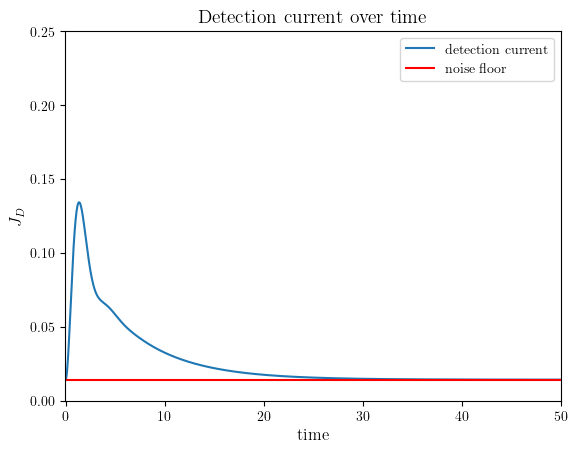

In [15]:
parameters["t_f"]=50
parameters["t_steps"]=1000
parameters["TC"]=0.1
parameters["Tb"]=parameters["TC"]
parameters["Td"]=parameters["TC"]
parameters["TH"]=1000
parameters["rateD"]=1
parameters["rateB"]=0.5
parameters["g_sl"]=1
parameters["e_C_factor"]=2
times=np.linspace(0,parameters["t_f"],parameters["t_steps"])
dynamics=get_dynamics_k_new(parameters)
result=dynamics[0]
steady_prev_run=dynamics[1]

fig, ax = plt.subplots()
plt1=plt.plot(times,result.expect[0],label="detection current")

e_ops=dynamics[2]

ax.set_ylim([0,0.25])
ax.set_xlim([-0.1,50])

ax.set_xlabel('time')
ax.set_ylabel('$J_D$')
ax.legend(("detection current", "ready state","Machine entropy production", "Machine heat draw"))
plt.title("Detection current over time")

noise_floor_curr=expect(e_ops[0],steady_prev_run)
plt.axhline(y=noise_floor_curr,color="red",label="noise floor")
ax.legend()

L,DI,init,steady=get_L_Draz_Init_Steady(parameters)

print(L_get_all_figures_of_merit(DI,init,steady,get_e_ops(parameters),parameters)[["efficiency","jitter","dark count rate", "entropy production"]])
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/transient_dyn_1.eps', format='eps')

In [202]:
Lright=L.eigenstates()
Lleft=L.dag().eigenstates()
eigvals_R=Lright[0]
eigvals_L=Lleft[0]
eigvecs_L=Lleft[1]
eigvecs_R=Lright[1]

In [230]:
from scipy.linalg import null_space

def find_eigenvector_null_space(A, lambda_val):
    M = A - lambda_val * np.eye(A.shape[0])
    return null_space(M).flatten()  # Return as a 1D array

eigenvector = find_eigenvector_null_space(L, eigvals_R[10])
print("Eigenvector:", eigenvector)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [204]:
import numpy as np

# Sort eigenvalues for a direct comparison
eigvals_R_sorted = np.sort(eigvals_R)
eigvals_L_sorted = np.sort(eigvals_L)

# Compare sorted eigenvalues
if np.allclose(np.real(eigvals_R_sorted), np.real(eigvals_L_sorted), atol=1e-8):
    print("Eigenvalues match after sorting.")
else:
    print("Eigenvalues still do not match, something is wrong!")

    # Identify and print mismatched eigenvalues
    mismatched_indices = np.where(~np.isclose(eigvals_R_sorted, eigvals_L_sorted, atol=1e-5))[0]
    if mismatched_indices.size > 0:
        print("Mismatched eigenvalues:")
        for idx in mismatched_indices:
            print(f"Index {idx}: Right = {eigvals_R_sorted[idx]}, Left = {eigvals_L_sorted[idx]}")
    else:
        print("All eigenvalues match.")

        # Create a list of eigenvalue-eigenvector pairs for matching eigenvalues
        eigenvector_pairs = []
        for idx, eigval in enumerate(eigvals_R_sorted):
            # Find the corresponding index in the left eigenvalues
            left_idx = np.where(np.isclose(eigvals_L_sorted, eigval, atol=1e-5))[0]
            if left_idx.size > 0:
                # Append the eigenvalue and the corresponding eigenvectors
                eigenvector_pairs.append((eigval, (Lright[1][idx], Lleft[1][left_idx[0]])))

        # Print the list of eigenvalue-eigenvector pairs
        for eigval, (right_vec, left_vec) in eigenvector_pairs:
            print(f"Eigenvalue: {eigval}")
            print(f"Right Eigenvector: {right_vec}")
            print(f"Left Eigenvector: {left_vec}")

Eigenvalues match after sorting.


In [ ]:
import numpy as np

# Sort indices by eigenvalues
sorted_R_indices = np.argsort(eigvals_R)
sorted_L_indices = np.argsort(np.conjugate(eigvals_L))

# Reorder eigenvalues
eigvals_R_sorted = eigvals_R[sorted_R_indices]
eigvals_L_sorted = eigvals_L[sorted_L_indices]

# Reorder eigenvectors
eigvecs_R_sorted = eigvecs_R[sorted_R_indices]
eigvecs_L_sorted = eigvecs_L[sorted_L_indices]  # Use manually computed left eigenvectors


/home/manu/MEGA/Meine_Uni/Uni/Apollaro_Group/Projects/01-Thermodynamics_of_Precision/Python_Code/Jupyter_Notebooks/qutip503env/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


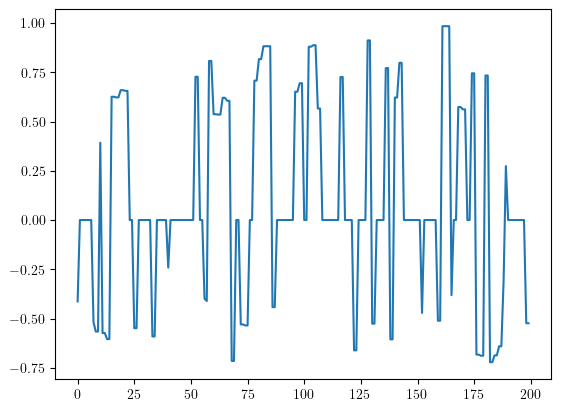

In [224]:
plt.plot([eigvecs_L_sorted[i].dag()*eigvecs_R_sorted[i] for i in range(200)])

In [118]:
import numpy as np
from scipy.spatial.distance import cdist

# Sort indices by eigenvalues (real part first, then imaginary)
sorted_R_indices = np.lexsort((eigvals_R.imag, eigvals_R.real))
sorted_L_indices = np.lexsort((eigvals_L.imag, eigvals_L.real))

# Reorder eigenvalues
eigvals_R_sorted = eigvals_R[sorted_R_indices]
eigvals_L_sorted = eigvals_L[sorted_L_indices]

# Reorder eigenvectors accordingly
eigvecs_R_sorted = [eigvecs_R[i] for i in sorted_R_indices]
eigvecs_L_sorted = [eigvecs_L[i] for i in sorted_L_indices]

# Check if they now match
if np.allclose(eigvals_R_sorted, np.conjugate(eigvals_L_sorted), atol=1e-6):
    print("Eigenvalues match after reordering.")
else:
    print("Reordering did not fix the mismatch!")


Reordering did not fix the mismatch!


plot 1 stdev:  0.1255496291362266
plot 2 stdev:  0.042325820962078584
plot 1 mean:  0.11419810284380831
plot 2 mean:  0.031248265801686638
plot 1
   efficiency    jitter  dark count rate  entropy production
0    0.596421  2.925756         0.021839            3.291899
plot 2
   efficiency      jitter  dark count rate  entropy production
0    0.591022  222.929347         0.000501            3.761146


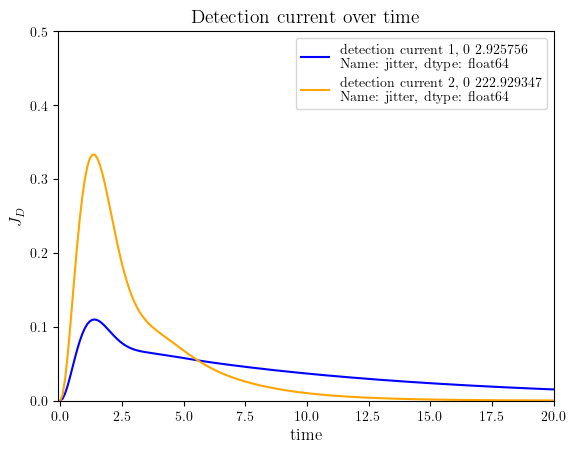

In [254]:
parameters["t_f"]=100
parameters["t_steps"]=1000
parameters["TC"]=0.1
parameters["Tb"]=parameters["TC"]
parameters["Td"]=parameters["TC"]
parameters["TH"]=1000
parameters["rateD"]=1
parameters["rateB"]=0.5
parameters["g_sl"]=1
parameters["e_C_factor"]=0.01
times=np.linspace(0,parameters["t_f"],parameters["t_steps"])


dynamics1=get_dynamics_k_new(parameters)
result1=dynamics1[0]
steady_prev_run1=dynamics1[1]
fig, ax = plt.subplots()

e_ops1=dynamics1[2]
noise_floor_curr1=expect(e_ops1[0],steady_prev_run1)


L,DI,init,steady=get_L_Draz_Init_Steady(parameters)
fom1=L_get_all_figures_of_merit(DI,init,steady,get_e_ops(parameters),parameters)
plt1=plt.plot(times,(result1.expect[0]-noise_floor_curr1)/fom1["efficiency"].values[0],label=f"detection current 1, {fom1['jitter']}",color="blue")

print("plot 1 stdev: ",np.sqrt((times*(result1.expect[0]-noise_floor_curr1)/fom1["efficiency"].values[0]).var()))

parameters["e_C_factor"]=1
# parameters["TC"]=1


dynamics2=get_dynamics_k_new(parameters)
result2=dynamics2[0]
steady_prev_run2=dynamics2[1]

e_ops2=dynamics2[2]
noise_floor_curr2=expect(e_ops2[0],steady_prev_run2)


L,DI,init,steady=get_L_Draz_Init_Steady(parameters)
fom2=L_get_all_figures_of_merit(DI,init,steady,get_e_ops(parameters),parameters)
plt2=plt.plot(times,(result2.expect[0]-noise_floor_curr2)/fom2["efficiency"].values[0],label=f"detection current 2, {fom2['jitter']}",color="orange")

print("plot 2 stdev: ",np.sqrt(((result2.expect[0]-noise_floor_curr2)/fom2["efficiency"].values[0]).var()))

ax.set_ylim([0,0.5])
ax.set_xlim([-0.1,20])

ax.set_xlabel('time')
ax.set_ylabel('$J_D$')
ax.legend(("detection current", "ready state","Machine entropy production", "Machine heat draw"))
plt.title("Detection current over time")



# plt.axhline(y=noise_floor_curr1,color="red",label="noise floor 1")
# plt.axhline(y=noise_floor_curr2,color="green",label="noise floor 2")
ax.legend()

print("plot 1 mean: ",(times*(result1.expect[0]-noise_floor_curr1)/fom1["efficiency"].values[0]).mean())
print("plot 2 mean: ",(times*(result2.expect[0]-noise_floor_curr2)/fom2["efficiency"].values[0]).mean())


print("plot 1")
print(fom1[["efficiency","jitter","dark count rate", "entropy production"]])
print("plot 2")
print(fom2[["efficiency","jitter","dark count rate", "entropy production"]])
# fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/transient_dyn_1.eps', format='eps')

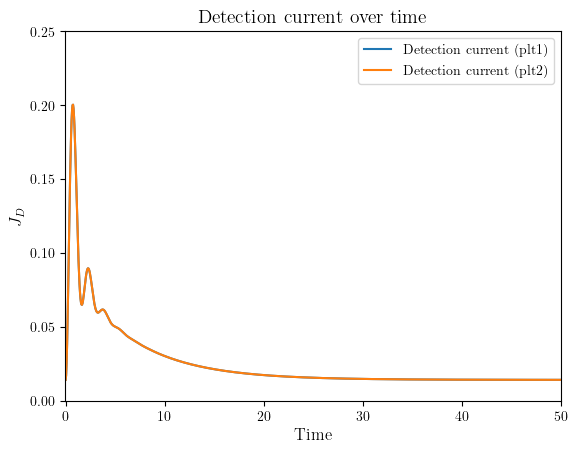

In [ ]:
fig, ax = plt.subplots()
plt1 = plt.plot(times, result.expect[0], label="Detection current (plt1)")
plt2 = plt.plot(times, result.expect[0], label="Detection current (plt2)")

ax.set_ylim([0, 0.25])
ax.set_xlim([-0.1, 50])

ax.set_xlabel('Time')
ax.set_ylabel('$J_D$')
ax.legend(("Detection current (plt1)", "Detection current (plt2)"))
plt.title("Detection current over time")
plt.show()

# Figures of Merit plots

## Optimisation

In this part I try to optimize e.g. the efficiency over a range of parameters to see if there is a fundamental trade-off relation

In [3]:
from scipy.optimize import minimize
import numpy as np


def objective(params, parameters):
        TC, TV, g_ml, rateD = params
        parameters.update({"TC": TC, "TV": TV, "g_ml": g_ml, "rateD": rateD})

        # Set additional parameters
        parameters["Tb"] = parameters["TC"]
        parameters["Td"] = parameters["TC"]

        # Compute TH
        parameters["TH"] = TH_from_TV_TC(
            parameters["TV"], parameters["TC"],
            parameters["e_l"] * parameters["e_C_factor"],
            parameters["e_l"]
        )

        # Hamiltonian
        H = (
            H0_k(parameters["e_s"], parameters["e_l"], parameters["e_C"],
                parameters["d_l"], parameters["k"])
            + HI_k(parameters["g_sl"], parameters["g_ml"],
                parameters["d_l"], parameters["k"])
        )

        # Jump operators and Liouvillian
        e_ops = get_e_ops(parameters)
        c_ops = c_ops_k(
            parameters["rateM"], parameters["rateB"], parameters["rateD"], parameters["TH"],
            parameters["TC"], parameters["Tb"], parameters["Td"], parameters["e_s"],
            parameters["e_C"], parameters["e_l"], parameters["d_l"], parameters["k"]
        )

        l = liouvillian(H, c_ops)
        drinv = pseudo_inverse(l, method="spsolve")
        steady = steadystate(H, c_ops)

        # Initial state for efficiency calculation
        init = operator_to_vector(tensor(
            ptrace(steady, [0, 1, 2]),
            matrix_element(1, 1, 2)
        ))

        # Compute efficiency
        efficiency = L_efficiency(drinv, init, e_ops, parameters)

        # print(f"Params: {parameters} | Efficiency: {efficiency}")

        return -efficiency  # We minimize, so return negative efficiency
def constraint_TH(params, parameters):
        """ Ensures TH >= constraint_value """
        TC, TV, _, _ = params
        TH = TH_from_TV_TC(
            TV, TC,
            parameters["e_l"] * parameters["e_C_factor"],
            parameters["e_l"]
        )
        constraint_value = TC * (parameters["e_l"] + parameters["e_C"]) / (parameters["e_l"] * parameters["e_C_factor"])
        return TH - constraint_value  # Must be >= 0
def constraint_dark_count(params, parameters):
    """ Ensures dark_count = target_dark_count_rate """
    TC, TV, g_ml, rateD = params
    parameters.update({"TC": TC, "TV": TV, "g_ml": g_ml, "rateD": rateD})

    # Set additional parameters
    parameters["Tb"] = parameters["TC"]
    parameters["Td"] = parameters["TC"]

    # Compute TH
    parameters["TH"] = TH_from_TV_TC(
        parameters["TV"], parameters["TC"],
        parameters["e_l"] * parameters["e_C_factor"],
        parameters["e_l"]
    )

    # Hamiltonian
    H = (
        H0_k(parameters["e_s"], parameters["e_l"], parameters["e_C"],
            parameters["d_l"], parameters["k"])
        + HI_k(parameters["g_sl"], parameters["g_ml"],
            parameters["d_l"], parameters["k"])
    )

    # Jump operators and Liouvillian
    e_ops = get_e_ops(parameters)
    c_ops = c_ops_k(
        parameters["rateM"], parameters["rateB"], parameters["rateD"], parameters["TH"],
        parameters["TC"], parameters["Tb"], parameters["Td"], parameters["e_s"],
        parameters["e_C"], parameters["e_l"], parameters["d_l"], parameters["k"]
    )


    drinv = 0
    steady = steadystate(H, c_ops)

    # Compute dark count
    dark_count = L_dark_counts(drinv, steady, e_ops, parameters)

    return target_dark_count_rate - dark_count  # Must be = 0


target_dark_count_rate_list=np.linspace(8*10**(-9),10**(-8),10)

optimal_params_list=[]
optimal_efficiency_list=[]

for target_dark_count_rate in target_dark_count_rate_list:
    # Define bounds for each parameter
    bounds = [
        (0.1, 1),   # TC
        (-10, -0.05), # TV
        (0.1, 1),   # g_ml
        (0.1, 10)    # rateD
    ]

    # Objective function (maximize efficiency)


    # **Constraint functions (must be >= 0 to be satisfied)**

    # Define constraints
    constraints = [
        {"type": "ineq", "fun": constraint_TH, "args": (parameters,)},   # TH constraint
        {"type": "eq", "fun": constraint_dark_count, "args": (parameters,)}  # Dark count constraint
    ]

    # Initial guess for parameters
    x0 = [0.5, -5, 0.5, 0.5]  # Choose reasonable initial values

    # Run optimization
    result = minimize(objective, x0, args=(parameters,), bounds=bounds, constraints=constraints, method="SLSQP")

    # Extract optimal parameters
    optimal_params = result.x
    optimal_efficiency = -result.fun  # Convert back from minimization

    optimal_params_list.append(optimal_params)
    optimal_efficiency_list.append(optimal_efficiency)

    # print("Optimal Parameters:", optimal_params)
    # print("Optimal Efficiency:", optimal_efficiency)


/home/manu/MEGA/Meine_Uni/Uni/Apollaro_Group/Projects/01-Thermodynamics_of_Precision/Python_Code/Jupyter_Notebooks/qutip503env/lib/python3.10/site-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
/home/manu/MEGA/Meine_Uni/Uni/Apollaro_Group/Projects/01-Thermodynamics_of_Precision/Python_Code/Jupyter_Notebooks/qutip503env/lib/python3.10/site-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
/home/manu/MEGA/Meine_Uni/Uni/Apollaro_Group/Projects/01-Thermodynamics_of_Precision/Python_Code/Jupyter_Notebooks/qutip503env/lib/python3.10/site-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outsid

KeyboardInterrupt: 

## Random sampling data sets


Sampling from uniform distributions first, and later maybe from Latin Hypercube sampling

Parameters that are random sampled and parameter range

$d\in [3,40]$

$R_B\in [0.01,2]$

$T_H \in [0.01, 10]$

$T_C \in [0.01,10]$ with the constraint that $\frac{E_C}{E_H}T_H\geq T_C$ to stay in the heat engine regime

$E_{max} \in [0.1,10]$ (will be fixed for now at $5$)

$E_f \in [0.01,1]$ (will be fixed for now at $0.1$)



### Generating Latin Hypercube random sample data sets

#### Sampling over $T_C$, $T_V$, $g_{ml}$, $g_{sl}$, $e_ {C-\mathrm{factor}}$ and $R_M$

In [120]:
import warnings
import pandas as pd
#Sampling ranges

rateD_range=[0.1,2]
g_ml_range=[0.1,2]
g_sl_range=[0.1,2]
T_C_range=[0.05,2]
T_V_range=[-10,-0]
e_C_factor_range=[0.01,2]
rateM_range=[0.1,2]

parameters["rateB"]=0.5

filename="FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v6"

parameters["Max_TV_flag"]=False

parameters["k"]=1
n=0
errors=0

while n < 500:
    try:
        # Generate sample set
        sample_set = np.array(generate_sample_set_TC_TV_g_ml_g_sl_rateD_eCfactor_rateM(
            T_C_range, T_V_range,g_ml_range, g_sl_range, rateD_range, e_C_factor_range, rateM_range, parameters, 10))

        # Generate dataset
        dset = generate_dataset_TC_TV_g_ml_g_sl_rateD_eCfactor_rateM(sample_set, filename, parameters)

        print(f"Sample set no. {n}, dataset size {np.array(dset).shape}", end="\r", flush=True)
        n += 1  # Increment only on success

    except (ValueError, RuntimeError) as e:
        errors += 1
        print(f"Error encountered: {type(e).__name__}: {e}. ..................(total errors: {errors})", end="\r", flush=True)
    except Exception as e:
        errors += 1
        print(f"Unexpected error encountered: {type(e).__name__}: {e}. ..................(total errors: {errors})", end="\r", flush=True)

    if errors > 100:
        print("\nToo many errors, stopping execution.")
        break

if errors > 0:
    print(f"\nCompleted with {errors} errors during execution.")
else:
    print("\nExecution completed without errors.")


 ** On entry to ZGEMV  parameter number  2 had an illegal value
 ** On entry to ZGEMV  parameter number  2 had an illegal value......(total errors: 1)
Sample set no. 499, dataset size (8530, 31)ngular. ..................(total errors: 2)
Completed with 2 errors during execution.


##### With max $T_V$

In [ ]:
import warnings
import pandas as pd
#Sampling ranges

rateD_range=[1,2]
g_ml_range=[0.5,2]
g_sl_range=[0.5,2]
T_C_range=[0.00,0.01]
e_C_factor_range=[0.01,2]
rateM_range=[0.5,2]


filename="FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1"


parameters["Max_TV_flag"]=True


parameters["k"]=1
n=0
errors=0

while n < 500:
    try:
        # Generate sample set
        sample_set = np.array(generate_sample_set_TC_MaxTV_g_ml_g_sl_rateD_eCfactor_rateM(
            T_C_range,g_ml_range, g_sl_range, rateD_range, e_C_factor_range, rateM_range, parameters, 10))

        # Generate dataset
        dset = generate_dataset_TC_MaxTV_g_ml_g_sl_rateD_eCfactor_rateM(sample_set, filename, parameters)

        print(f"Sample set no. {n}, dataset size {np.array(dset).shape}", end="\r", flush=True)
        n += 1  # Increment only on success

    except (ValueError, RuntimeError) as e:
        errors += 1
        print(f"Error encountered: {type(e).__name__}: {e}. ..................(total errors: {errors})", end="\r", flush=True)
    except Exception as e:
        errors += 1
        print(f"Unexpected error encountered: {type(e).__name__}: {e}. ..................(total errors: {errors})", end="\r", flush=True)

    if errors > 100:
        print("\nToo many errors, stopping execution.")
        break

if errors > 0:
    print(f"\nCompleted with {errors} errors during execution.")
else:
    print("\nExecution completed without errors.")


KeyboardInterrupt: 

#### Sampling over $T_C$, $T_V$, $g_{ml}$ and $R_D$

In [184]:
import warnings
import pandas as pd
#Sampling ranges

rateD_range=[0.5,2]
g_ml_range=[0.5,2]
T_C_range=[0.005,2]
T_V_range=[-20,-0]

####!!!! These are only valid for efficiency and dark count rate, as we dont need the transient for them !!!!#########
parameters["t_f"]=1
parameters["t_steps"]=10
########################################################################################################################

filename="FOM_Dinv_exact_v5"

parameters["k"]=1
n=0
errors=0

while n < 200:
    try:


        # Generate sample set
        sample_set = np.array(generate_sample_set_TC_TV_g_ml_rateD(
            T_C_range, T_V_range, g_ml_range, rateD_range,parameters, 10))

        # Generate dataset
        dset = generate_dataset_TC_TV_g_ml_rateD(sample_set, filename, parameters)

        print(f"Sample set no. {n}, dataset size {np.array(dset).shape}", end="\r", flush=True)
        n += 1  # Increment only on success

    except ValueError as e:
        errors += 1
        print(f"ValueError encountered: {e}. ..................(total errors: {errors})", end="\r", flush=True)
    if errors > 100:
        break
if errors > 0:
    print(f"Completed with {errors} errors during execution.")
else:
    print("Execution completed without errors.")

RuntimeError: failed to factorize matrix at line 441 in file ../scipy/sparse/linalg/_dsolve/SuperLU/SRC/zpanel_bmod.c


#### Sampling over $T_C$, $g_{ml}$ and $R_D$ while keeping $T_V=-T_C/e_{C-factor}$

In [ ]:
import warnings
import pandas as pd
#Sampling ranges

rateD_range=[0.5,2]
g_ml_range=[0.5,2]
T_C_range=[0.005,2]

parameters["Max_TV_flag"]=True


####!!!! These are only valid for efficiency and dark count rate, as we dont need the transient for them !!!!#########
parameters["t_f"]=1
parameters["t_steps"]=10
########################################################################################################################

filename="FOM_Dinv_exact_MaxTV_v1"

parameters["k"]=1
n=0
errors=0

while n < 600:
    try:


        # Generate sample set
        sample_set = np.array(generate_sample_set_TC_MaxTV_g_ml_rateD(
            T_C_range,g_ml_range, rateD_range,parameters, 10))
        # Generate dataset
        dset = generate_dataset_TC_MaxTV_g_ml_rateD(sample_set, filename, parameters)

        print(f"Sample set no. {n}, dataset size {np.array(dset).shape}", end="\r", flush=True)
        n += 1  # Increment only on success

    except ValueError as e:
        errors += 1
        print(f"ValueError encountered: {e}. ..................(total errors: {errors})", end="\r", flush=True)
    if errors > 100:
        break
if errors > 0:
    print(f"Completed with {errors} errors during execution.")
else:
    print("Execution completed without errors.")

KeyboardInterrupt: 

### Correlation Matrix

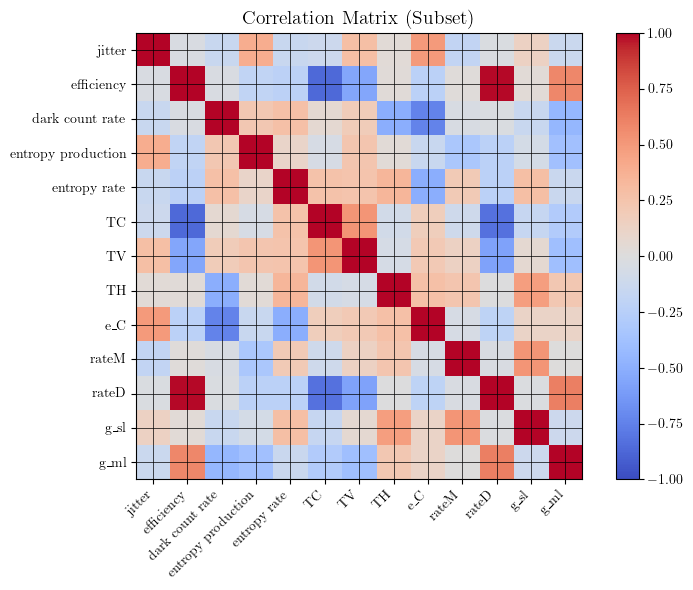

In [ ]:

dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v5")
dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v3")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v2")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v1")])
# corr_matrix = dset.corr()

## Constraints
condition = dset["k"]==1

# condition &= dset["efficiency"] >0
# condition &= dset["efficiency"] <1
# condition &= dset["e_C_factor"] <1
# condition &= dset["rateM"] <1
# condition &= dset["rateD"] <1
# condition &= dset["g_ml"] <1
# condition &= dset["g_sl"] <1

condition &= dset["entropy production"] >0

# condition &= dset["entropy production"]>0.5
# condition &= dset["entropy production"]<0.51

# condition &= dset["jitter"]<10

# condition &= dset["TC"]<1
# condition &= dset["TC"]>0.9
# condition &= dset["TV"]<-4
# condition &= dset["TV"]>-5

# condition &= dset["e_C_factor"]<1
# condition &= dset["e_C_factor"]>0.9

condition &= dset["entropy production"]<5
condition &= dset["entropy production"]>4

condition &= dset["g_sl"]<1
condition &= dset["g_sl"]>0.9

condition &= dset["g_ml"]<1
condition &= dset["g_ml"]>0.5

dset=dset[condition]

# Select a subset of columns to analyze
subset = ['jitter', 'efficiency', 'dark count rate', 'entropy production',"entropy rate","TC","TV","TH", "e_C", "rateM","rateD","g_sl","g_ml"]  # Replace with your column names
corr_matrix = dset[subset].corr()

# Plot the correlation matrix using Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', vmin=-1, vmax=1)
plt.colorbar()

# Add grid lines
plt.grid(which='both', color='black', linestyle='-', linewidth=0.5)

# Add labels
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

plt.title("Correlation Matrix (Subset)")
plt.tight_layout()
plt.show()


### Scatter plots

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


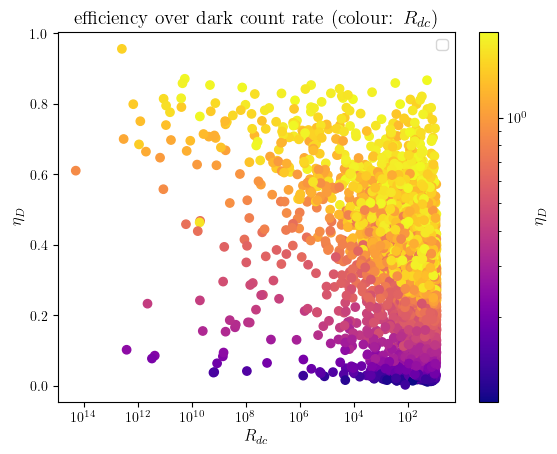

In [156]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v6")


# dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v5")
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v3")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v2")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v1")])
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.0
condition &= dset["efficiency"] <1
# condition &= dset["rateD"] >15
# condition &= dset["rateD"] <0.8
# condition &= dset["g_ml"] >10
# condition &= dset["g_ml"] <12

# condition &= dset["TC"] >0.7
# condition &= dset["TC"] <0.1
# condition &= dset["TV"] <-3
# condition &= dset["TV"] >-4
# condition &= dset["TH"] >dset["TC"]*(dset["e_l"]+dset["e_C"])/dset["e_C"]

# condition &= dset["TV"] < -5
# condition &= dset["g_ml"] <1

# condition &=  ((dset["jitter"] < 7) | ((dset["jitter"] < 10) & (dset["jitter"] > 9)) | ((dset["jitter"] < 15) & (dset["jitter"] > 14)))


# condition &= dset["entropy production"] >1
condition &= dset["entropy production"] >0.0

# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000



# condition &= ((dset["rateD"]<0.6)& (dset["rateD"]>0.5))| ((dset["rateD"]<1)&( dset["rateD"]>0.9))| ((dset["rateD"]<1.5)&( dset["rateD"]>1.4))
# condition &= dset["rateD"]>0.9

# condition &= dset["rateD"]<1.7
# condition &= dset["rateD"]>1.6

# condition &= dset["g_ml"]<2
# condition &= dset["g_ml"]>

# condition &= dset["jitter"]<10**10
condition &= dset["jitter"]>9.01

# condition &= dset["rateM"]<0.9
# condition &= dset["dark count rate"]<10**(-4)

# condition &= dset["entropy production"]<1
# condition &= dset["entropy production"]>0.1

# condition &= dset["entropy rate"] >0
# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000

rdval=2
# condition &= dset["e_C_factor"] <1
# condition &= dset["rateM"] <1
# condition &= dset["rateD"] <1
# condition &= dset["g_ml"] <1
# condition &= dset["g_sl"] <1

# condition &= dset["entropy production"]>0.5
# condition &= dset["entropy production"]<0.51
# condition &= ((dset["TC"]<0.3) & dset["TC"]>0.25)

# condition &= dset["efficiency"]>0.4
# condition &= dset["efficiency"]<0.5
# condition &= dset["jitter"]<5
# condition &= dset["jitter"]<100
# condition &= dset["rateB"]==0.8

dset=dset[condition]




fig, ax = plt.subplots()
ax.set_xlabel("$R_{dc}$")
ax.set_ylabel("$\eta_D$")

plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()

# ax.set_yscale('log')
ax.set_xscale('log')

# ax.set_ylim([0,1])

Ladder_B_abs_rate=np.exp(-dset["e_s"].values/dset["TC"].values)*dset["rateB"].values
Ladder_D_abs_rate=np.exp(-(dset["e_s"].values+dset["e_l"].values)/dset["TC"].values)*dset["rateD"].values

plt.title("efficiency over dark count rate (colour: $R_{dc}$)")
scatter=plt.scatter(dset["jitter"].values,
                    dset["efficiency"].values,
                    c=dset["rateD"].values,
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )

# for i in range(1,len(data)):
#     plt.plot(np.array(data[i]) [:-2,out_index("dark count rate")],np.array(data[i])[:-2,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")]))

# Plot linear function
# x = np.linspace(min(1/(dset["rateB"].values/dset["rateD"].values+1)), max(1/(dset["rateB"].values/dset["rateD"].values+1)), 100)
# y = x # Example linear function
# plt.plot(x, y, label='Eyeballed function: $y =1/4 x^{1/4}$', color='blue',linestyle="--")

# Define the inverse function with an exponent a

# def inverse_func(x, a, b):
#     return a / (x ** b)

# # Fit the data with increased maxfev
# popt, pcov = curve_fit(inverse_func, dset["dark count rate"].values, dset["jitter"].values,maxfev = 100)

# # Plot the fitted curve
# x_fit = np.linspace(min(dset["dark count rate"]), max(dset["dark count rate"]), 100)
# y_fit = inverse_func(x_fit, *popt)
# plt.plot(x_fit, y_fit, label=f'Fitted function: y = {popt[0]:.2f} / x^{popt[1]:.2f}', color='blue')

plt.colorbar(scatter, label="$\eta_D$")
plt.legend()

In [99]:
get_parameter_range_of_dataset(dset)["rateB"]

0    [0.5, 0.5]
Name: rateB, dtype: object

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


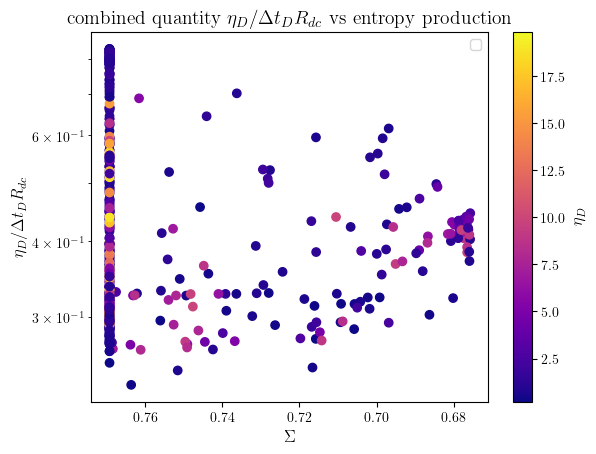

In [39]:


dset= pd.read_csv("FOM_Dinv_exact_v5")
dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_MaxTV_v1")])
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

condition = dset["k"] == 1
# condition &= dset["efficiency"] >0.7
condition &= dset["efficiency"] <1
# condition &= dset["rateD"] >15
# condition &= dset["rateD"] <1
# condition &= dset["g_ml"] <1
# condition &= dset["g_ml"] <12

# condition &= dset["TC"] >0.6
# condition &= dset["TC"] <0.8
# condition &= ((dset["TV"] <-3) & (dset["TV"] >-4))


# condition &= dset["TC"] < 1.25
# condition &= dset["TC"] > 0.5

# condition &= dset["TH"] >dset["TC"]*(dset["e_l"]+dset["e_C"])/dset["e_C"]


###
# condition &= ((dset["TV"] > -5)& (dset["TV"] < -4.9))

# condition &= dset["efficiency"] >0.5

# condition &= dset["g_ml"] <1

# condition &=  ((dset["jitter"] < 7) | ((dset["jitter"] < 15) & (dset["jitter"] > 14)))

# condition &=  (dset["jitter"] < 12)
# condition &= dset["efficiency"] >0.7


# condition |= dset["jitter"] <50
# condition |= dset["jitter"] >30

# condition &= dset["jitter"] <200
# condition |= dset["jitter"] >80

# condition &= dset["entropy production"] >0.0
# condition &= dset["entropy production"] <200

# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000



condition &= dset["rateD"]<2
condition &= dset["rateD"]>1.7

# condition &= dset["g_ml"]<10
# condition &= dset["g_ml"]>0.5

dset=dset[condition]

fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma$")
ax.set_ylabel("$\eta_D/\Delta t_D R_{dc}$")

# ax.set_ylim(0, 1.2)
# ax.set_xlim(2, 100)
plt.gca().invert_xaxis()



ax.set_yscale('log')
# ax.set_xscale('log')
plt.title("combined quantity $\eta_D/\Delta t_D R_{dc}$ vs entropy production")


# for i in range(1,len(data)):
#     plt.plot(np.array(data[i]) [:-2,out_index("dark count rate")],np.array(data[i])[:-2,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")]))
# rd = np.linspace(0, 1, 100)

# analyticeff=[]
# rateee=[]
# for TC,e_s,e_l,rateB,rateD,effi in dset[["TC","e_s","e_l","rateB","rateD","efficiency"]].values:
#     aeff=(rateD * np.exp(-(e_s + e_l) / TC)/(1+rateD * np.exp(-(e_s + e_l) / TC))*1 /
#                        (rateB * np.exp(-e_s / TC))/(1+(rateB * np.exp(-e_s / TC)) +
#                         rateD/(1+rateD * np.exp(-(e_s + e_l) / TC)) * np.exp(-(e_s + e_l) / TC)))
#     analyticeff.append(aeff)

    # rateee.append(rateD)
    # print("analyt: ",aeff, "eff: ",effi)
# rb = np.exp(-0.1 / 1) / (1 + np.exp(-0.1 / 1))
# print(rb)
# plt.plot(rd, rb / (rd + rb), label="Analytic $\eta_D$")

# plt.scatter(dset["rateD"].values,np.array(analyticeff), label="Analytic $\eta_D$", color="green")

scatter=plt.scatter(dset["machine_efficiency"],
                    dset["efficiency"],
                    c=dset["g_ml"].values, cmap='plasma')



plt.colorbar(scatter, label="$\eta_D$")
plt.legend()

## One parameters plots

In [ ]:
plot_list=[]
for rateD in [0.1,.5,1]:
    parameters["rateD"]=rateD
    plot_list.append(L_get_FoM_vari_one_parameter(parameters,"g_ml",np.linspace(0.001,10,50)))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


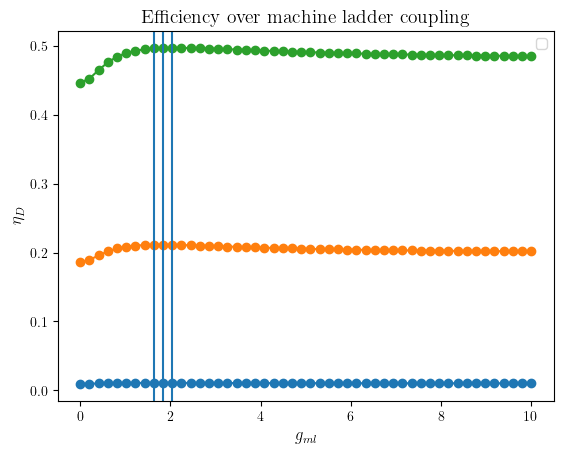

In [107]:
fig, ax = plt.subplots()
ax.set_xlabel("$g_{ml}$")
ax.set_ylabel("$\eta_D$")

[plt.plot(plot["g_ml"].values,plot["efficiency"].values,marker="o") for plot in plot_list]
plt.axvline(x=plot_list[0][plot_list[0]["efficiency"]==max(plot_list[0]["efficiency"])]["g_ml"].values[0])
plt.axvline(x=plot_list[1][plot_list[1]["efficiency"]==max(plot_list[1]["efficiency"])]["g_ml"].values[0])
plt.axvline(x=plot_list[2][plot_list[2]["efficiency"]==max(plot_list[2]["efficiency"])]["g_ml"].values[0])

# ax.set_yscale('log')
# ax.set_xscale('log')
# plt.xlim(0,20)
plt.title("Efficiency over machine ladder coupling")

# Add a caption
# caption = (r"\textbf{Figure 1.} parameters: "
#            fr"$R_M$={rateM}, $R_B$={rateB}, $R_D$={rateD}, $T_H$={TH}, $T_C$={TC}, $T_B$={Tb}, $T_D$={Td},"
#            r" \\ \quad"fr"$e_S$={e_s}, $e_C${e_C:.3f}, $e_l$={e_l}, "r"$g_{sl}$="fr"{g_sl}, "r"$g_{ml}$="fr"{g_ml}, $d_l$={d_l}, $t_f=${t_f}, "r"$t_\mathrm{steps}=$"fr"{t_steps}, $k=${k}")

# caption = (
#     r"\textbf{Figure 1.} Parameters: \\"
#     fr"$R_M={rateM}, R_B={rateB}, R_D={rateD},T_H={TH} T_C={TC}, T_B={Tb}, T_D={Td},$ \\"
#     r"\quad "
#     fr"$e_S={e_s}, e_C={e_C:.3f}, e_l={e_l}, g_{{sl}}={g_sl}, g_{{ml}}={g_ml}, d_l={d_l},$ \\"
#     fr"$t_f={t_f}, t_{{\mathrm{{steps}}}}={t_steps}, k={k}$"
# )

# plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)
plt.legend()

In [6]:
L_get_FoM_vari_one_parameter(parameters,"rateD",np.linspace(0.001,1,50))["TC"]

KeyError: 'TC'

In [34]:
plot_list_2=[]
parameters["TC"]=0.2
parameters["g_ml"]=1
parameters["e_max"]=1
parameters["Tb_indep_flag"]=True
parameters["Td_indep_flag"]=True
parameters["Tb"]=0.6
parameters["Td"]=0.6
plot_list_2=pd.DataFrame()
for TV in [-0.5,-1,-2,-200]:
    parameters["TV"]=TV
    plot_list_2=pd.concat([plot_list_2,L_get_FoM_vari_one_parameter(parameters,"TC",np.linspace(0.1,0.2,50))])


Text(0.5, -0.1, '\\textbf{Figure 1.} Parameters: \\\\$R_M=1, R_B=0.8, R_D=1, T_H=10, T_C=0.2, T_B=0.6, T_D=0.6,$ \\\\\\quad $e_S=0.1, e_C=0.270, e_l=0.9, g_{sl}=1, g_{ml}=1, d_l=3,$ \\\\$t_f=3000, t_{\\mathrm{steps}}=3000, k=1$')

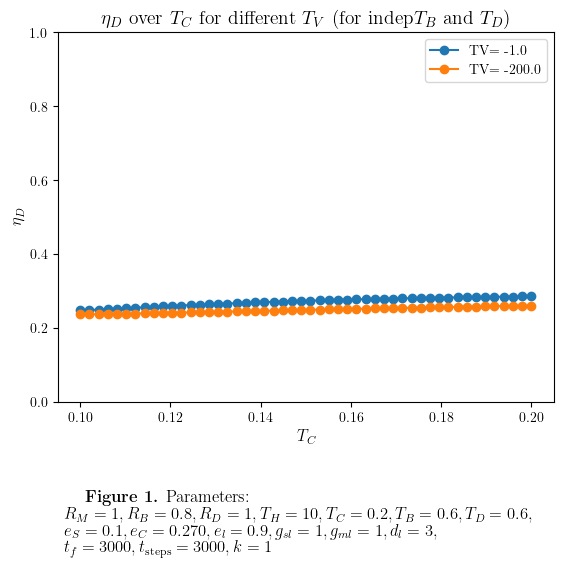

In [ ]:
fig, ax = plt.subplots()
ax.set_xlabel("$T_C$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_ylim(0, 1)
# plt.gca().invert_xaxis()

[plt.plot(plot_list_2[plot_list_2["TV"]==TV]["TC"].values,
          plot_list_2[plot_list_2["TV"]==TV]["efficiency"].values,
          marker="o",
          label=f"TV= {plot_list_2[plot_list_2['TV']==TV]['TV'].values[0]}")
            for TV in [-1,-200]]

plt.title("$\eta_D$ over $T_C$ for different $T_V$ (for indep$T_B$ and $T_D$)")

plt.legend()

caption = (
  r"\textbf{Figure 1.} Parameters: \\"
  fr"$R_M={parameters['rateM']}, R_B={parameters['rateB']}, R_D={parameters['rateD']}, T_H={parameters['TH']}, T_C={parameters['TC']}, T_B={parameters['Tb']}, T_D={parameters['Td']},$ \\"
  r"\quad "
  fr"$e_S={parameters['e_s']}, e_C={parameters['e_C']:.3f}, e_l={parameters['e_l']}, g_{{sl}}={parameters['g_sl']}, g_{{ml}}={parameters['g_ml']}, d_l={parameters['d_l']},$ \\"
  fr"$t_f={parameters['t_f']}, t_{{\mathrm{{steps}}}}={parameters['t_steps']}, k={parameters['k']}$"
)

plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

In [6]:
plot_list_2=[]
parameters["TC"]=0.05
parameters["g_ml"]=1
parameters["e_max"]=1


plot_list_2=pd.DataFrame()
for TV in [-0.5,-1,-2,-5,-10]:
    parameters["TV"]=TV
    plot_list_2=pd.concat([plot_list_2,L_get_FoM_vari_one_parameter(parameters,"rateD",np.logspace(-1,1.3,50))])


Text(0.5, -0.1, '\\textbf{Figure 1.} Parameters: \\\\$R_M=1, R_B=0.8, R_D=1, T_H=10, T_C=0.05, T_B=0.1, T_D=0.1,$ \\\\\\quad $e_S=0.1, e_C=1.470, e_l=4.9, g_{sl}=1, g_{ml}=1, d_l=3,$ \\\\$t_f=3000, t_{\\mathrm{steps}}=3000, k=1$')

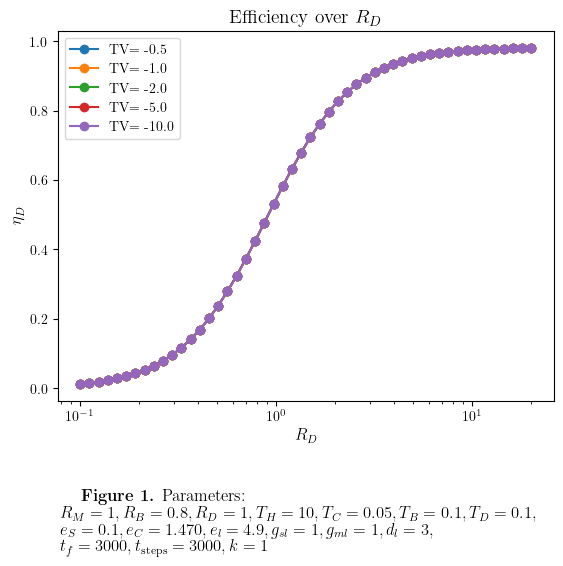

In [ ]:
fig, ax = plt.subplots()
ax.set_xlabel("$R_D$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
ax.set_xscale('log')

# plt.gca().invert_xaxis()

[plt.plot(plot_list_2[plot_list_2["TV"]==TV]["rateD"].values,
          plot_list_2[plot_list_2["TV"]==TV]["efficiency"].values,
          marker="o",
          label=f"TV= {plot_list_2[plot_list_2['TV']==TV]['TV'].values[0]}")
            for TV in [-0.5,-1,-2,-5,-10]]

plt.title("Efficiency over $R_D$")

plt.legend()

caption = (
  r"\textbf{Figure 1.} Parameters: \\"
  fr"$R_M={parameters['rateM']}, R_B={parameters['rateB']}, R_D={parameters['rateD']}, T_H={parameters['TH']}, T_C={parameters['TC']}, T_B={parameters['Tb']}, T_D={parameters['Td']},$ \\"
  r"\quad "
  fr"$e_S={parameters['e_s']}, e_C={parameters['e_C']:.3f}, e_l={parameters['e_l']}, g_{{sl}}={parameters['g_sl']}, g_{{ml}}={parameters['g_ml']}, d_l={parameters['d_l']},$ \\"
  fr"$t_f={parameters['t_f']}, t_{{\mathrm{{steps}}}}={parameters['t_steps']}, k={parameters['k']}$"
)

plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

In [ ]:
dset[condition]

plot_list_2=[]
parameters["TC"]=dset[condition]["TC"].values[0]
parameters["g_ml"]=dset[condition]["g_ml"].values[0]
parameters["e_max"]=dset[condition]["e_max"].values[0]
parameters["TV"]=dset[condition]["TV"].values[0]
parameters["TH"]=dset[condition]["TH"].values[0]
parameters["rateM"]=dset[condition]["rateM"].values[0]
parameters["rateB"]=dset[condition]["rateB"].values[0]
parameters["Td"]=dset[condition]["Td"].values[0]
parameters["Tb"]=dset[condition]["Tb"].values[0]
parameters["e_s"]=dset[condition]["e_s"].values[0]
parameters["e_l"]=dset[condition]["e_l"].values[0]



plot_list_2=pd.DataFrame()
for TV in [-0.5,-1,-2,-5,-10]:
    parameters["TV"]=TV
    plot_list_2=pd.concat([plot_list_2,L_get_FoM_vari_one_parameter(parameters,"rateD",np.linspace(0.1,5,100))])

/tmp/ipykernel_84089/2972694284.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dset[condition]
/tmp/ipykernel_84089/2972694284.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  parameters["TC"]=dset[condition]["TC"].values[0]
/tmp/ipykernel_84089/2972694284.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  parameters["g_ml"]=dset[condition]["g_ml"].values[0]
/tmp/ipykernel_84089/2972694284.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  parameters["e_max"]=dset[condition]["e_max"].values[0]
/tmp/ipykernel_84089/2972694284.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  parameters["TV"]=dset[condition]["TV"].values[0]
/tmp/ipykernel_84089/2972694284.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  parameters["TH"]=dset[condition]["TH"].values[0]
/tmp/ipykernel_84089/2972694284.p

Text(0.5, -0.1, '\\textbf{Figure 1.} Parameters: \\\\$R_M=1, R_B=0.8, R_D=2.4956292454006688, T_H=6.217709311406398, T_C=0.051063709223508, T_B=0.051063709223508, T_D=0.051063709223508,$ \\\\\\quad $e_S=0.1, e_C=0.270, e_l=0.9, g_{sl}=1, g_{ml}=0.9686924067412804, d_l=3,$ \\\\$t_f=1, t_{\\mathrm{steps}}=10, k=1$')

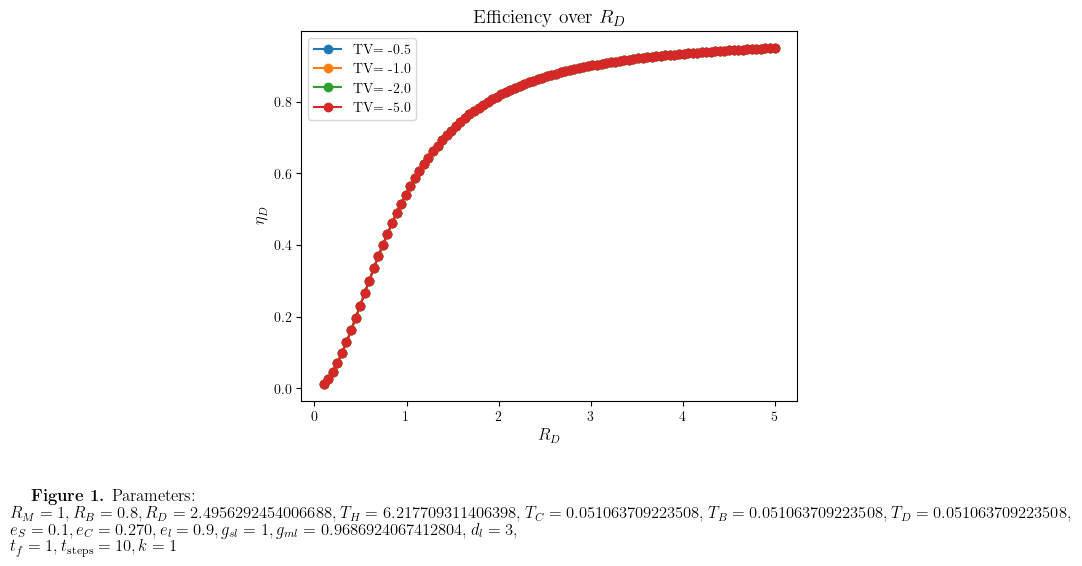

In [132]:
fig, ax = plt.subplots()
ax.set_xlabel("$R_D$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

[plt.plot(plot_list_2[plot_list_2["TV"]==TV]["rateD"].values,
          plot_list_2[plot_list_2["TV"]==TV]["efficiency"].values,
          marker="o",
          label=f"TV= {plot_list_2[plot_list_2['TV']==TV]['TV'].values[0]}")
            for TV in [-0.5,-1,-2,-5]]

plt.title("Efficiency over $R_D$")

plt.legend()

caption = (
  r"\textbf{Figure 1.} Parameters: \\"
  fr"$R_M={parameters['rateM']}, R_B={parameters['rateB']}, R_D={parameters['rateD']}, T_H={parameters['TH']}, T_C={parameters['TC']}, T_B={parameters['Tb']}, T_D={parameters['Td']},$ \\"
  r"\quad "
  fr"$e_S={parameters['e_s']}, e_C={parameters['e_C']:.3f}, e_l={parameters['e_l']}, g_{{sl}}={parameters['g_sl']}, g_{{ml}}={parameters['g_ml']}, d_l={parameters['d_l']},$ \\"
  fr"$t_f={parameters['t_f']}, t_{{\mathrm{{steps}}}}={parameters['t_steps']}, k={parameters['k']}$"
)

plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


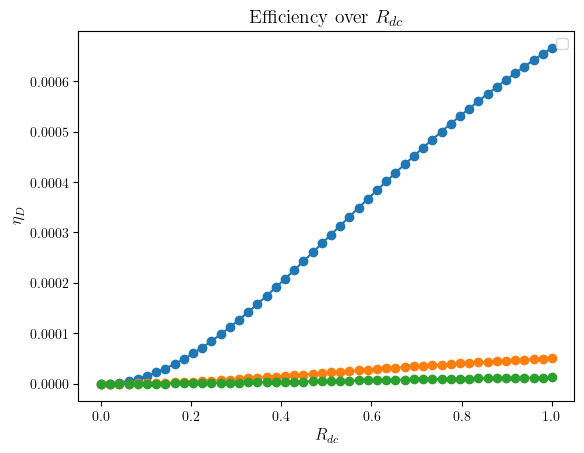

In [ ]:
fig, ax = plt.subplots()
ax.set_xlabel("$R_{dc}$")
ax.set_ylabel("$\eta_D$")

[plt.plot(plot["rateD"].values,plot["dark count rate"].values,marker="o") for plot in plot_list_2]

# ax.set_yscale('log')
# ax.set_xscale('log')
# plt.xlim(0,20)
plt.title("Efficiency over $R_{dc}$")


plt.legend()

In [4]:

parameters["g_ml"]=1
parameters["e_max"]=1
parameters["TV"]=-1

TV_list=pd.DataFrame()

for rateD in [0.1,0.5,1,5,10]:
    parameters["rateD"]=rateD
    TV_list=pd.concat([TV_list,L_get_FoM_vari_one_parameter(parameters,"TV",np.linspace(-10,-0.5,50))])


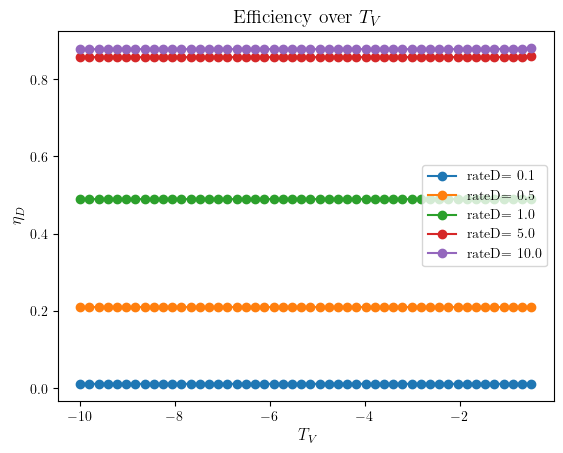

In [5]:
fig, ax = plt.subplots()
ax.set_xlabel("$T_V$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

[plt.plot(TV_list[TV_list["rateD"]==rateD]["TV"].values,
          TV_list[TV_list["rateD"]==rateD]["efficiency"].values,
          marker="o",
          label=f"rateD= {TV_list[TV_list['rateD']==rateD]['rateD'].values[0]}")
            for rateD in [0.1,0.5,1,5,10]]

plt.title("Efficiency over $T_V$")

plt.legend()

# dat_list.reset_index(drop=True, inplace=True)
# dat_list.to_csv("effic_over_jitter_plot.csv",index=False)

ValueError: param_str not basic parameter

In [ ]:
dat_list=pd.DataFrame()
parameters["Tb_indep_flag"]=False
parameters["Td_indep_flag"]=False

for TV in [-0.5,-1,-2,-5,-10]:
    parameters["TV"]=TV
    dat_list=pd.concat([dat_list,Parameter_plot(parameters,"TC",np.linspace(0.05,0.3,50))])


In [41]:
dat_list2=pd.DataFrame()
parameters["Tb_indep_flag"]=True
parameters["Td_indep_flag"]=True
parameters["Tb"]=1
parameters["Td"]=1
for TV in [-0.5,-1,-2,-5,-10]:
    parameters["TV"]=TV
    dat_list2=pd.concat([dat_list2,Parameter_plot(parameters,"TC",np.linspace(0.05,0.3,50))])

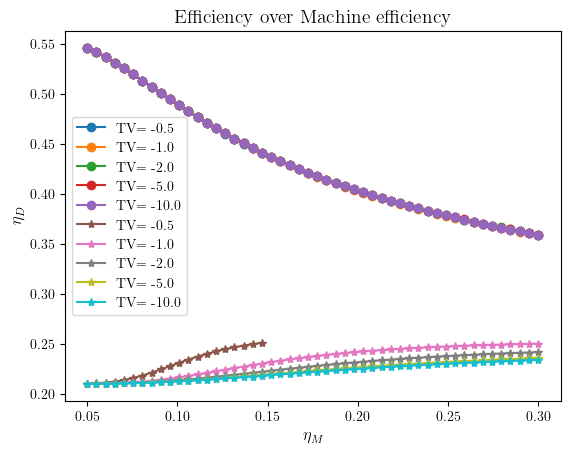

In [45]:
fig, ax = plt.subplots()
ax.set_xlabel("$\eta_M$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)

[plt.plot(dat_list[dat_list["TV"]==TV]["TC"].values,
          dat_list[dat_list["TV"]==TV]["efficiency"].values,
          marker="o",
          label=f"TV= {dat_list[dat_list['TV']==TV]['TV'].values[0]}")
            for TV in [-0.5,-1,-2,-5,-10]]

[plt.plot(dat_list2[dat_list2["TV"]==TV]["TC"].values,
          dat_list2[dat_list2["TV"]==TV]["efficiency"].values,
          marker="*",
          label=f"TV= {dat_list2[dat_list2['TV']==TV]['TV'].values[0]}")
            for TV in [-0.5,-1,-2,-5,-10]]


plt.title("Efficiency over Machine efficiency")

plt.legend()

dat_list.reset_index(drop=True, inplace=True)
dat_list.to_csv("effic_over_jitter_plot.csv",index=False)

In [13]:
dat_list3=pd.DataFrame()
parameters["Tb_indep_flag"]=True
parameters["Td_indep_flag"]=True
parameters["Tb"]=0.3
parameters["TC"]=0.3
for TV in [-1,-2,-5,-10]:
    parameters["TV"]=TV
    dat_list3=pd.concat([dat_list3,Parameter_plot(parameters,"Td",np.linspace(0.1,1,50))])

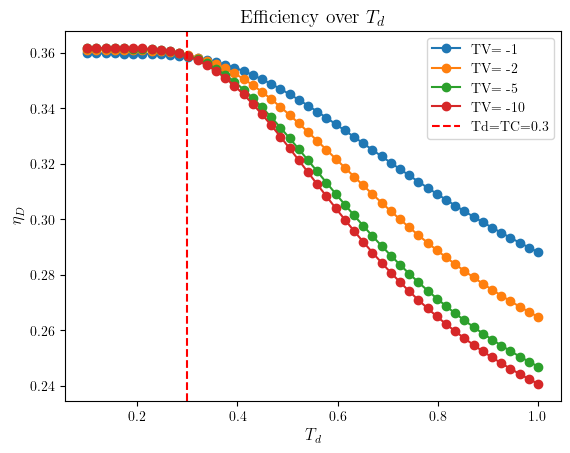

In [19]:
fig, ax = plt.subplots()
ax.set_xlabel("$T_d$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)

[plt.plot(dat_list3[dat_list3["TV"]==TV]["Td"].values,
          dat_list3[dat_list3["TV"]==TV]["efficiency"].values,
          marker="o",
          label=f"TV= {dat_list3[dat_list3['TV']==TV]['TV'].values[0]}")
            for TV in [-1,-2,-5,-10]]

plt.axvline(x=parameters["TC"], color='r', linestyle='--', label=f'Td=TC={parameters["Tb"]}')

plt.title("Efficiency over $T_d$")

plt.legend()

In [24]:
dat_list4=pd.DataFrame()
parameters["Tb_indep_flag"]=True
parameters["Td_indep_flag"]=True
parameters["Td"]=0.3
parameters["TC"]=0.3
for TV in [-1,-2,-5,-10]:
    parameters["TV"]=TV
    dat_list4=pd.concat([dat_list4,Parameter_plot(parameters,"Tb",np.linspace(0.1,1,50))])

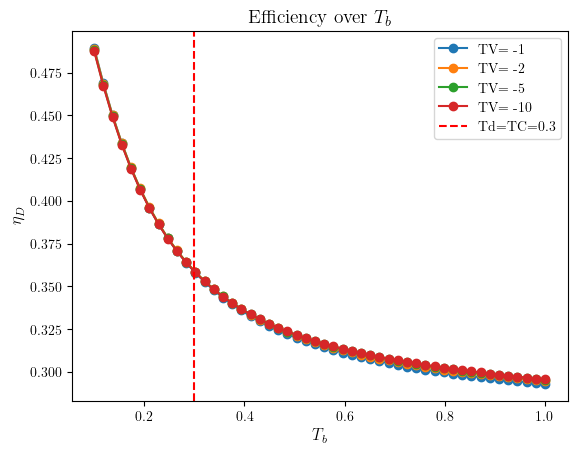

In [ ]:
fig, ax = plt.subplots()
ax.set_xlabel("$T_b$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)

[plt.plot(dat_list4[dat_list4["TV"]==TV]["Tb"].values,
          dat_list4[dat_list4["TV"]==TV]["efficiency"].values,
          marker="o",
          label=f"TV= {dat_list4[dat_list4['TV']==TV]['TV'].values[0]}")
            for TV in [-1,-2,-5,-10]]

plt.axvline(x=parameters["TC"], color='r', linestyle='--', label=f'Td=TC={parameters["Td"]}')


plt.title("Efficiency over $T_b$")

plt.legend()

In [ ]:
dat_list=pd.DataFrame()
for TC in [0.05,0.2,0.8]:
    parameters["TC"]=TC
    dat_list=pd.concat([dat_list,Parameter_plot(parameters,"TV",np.linspace(-20,0,50))])


KeyboardInterrupt: 

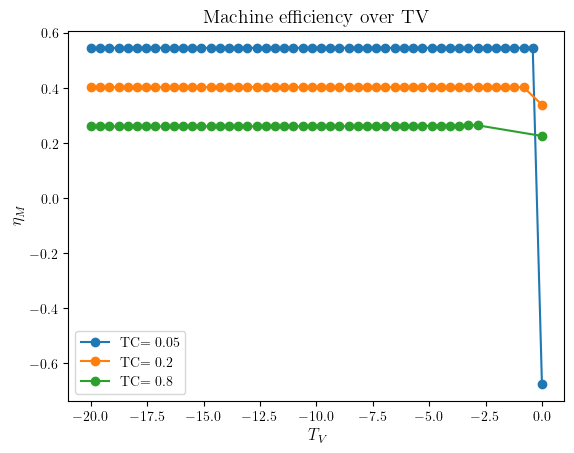

In [20]:
fig, ax = plt.subplots()
ax.set_xlabel("$T_V$")
ax.set_ylabel("$\eta_M$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)

[plt.plot(dat_list[dat_list["TC"]==TC]["TV"].values,
          dat_list[dat_list["TC"]==TC]["efficiency"].values,
          marker="o",
          label=f"TC= {dat_list[dat_list['TC']==TC]['TC'].values[0]}")
            for TC in [0.05,0.2,0.8]]

plt.title("Machine efficiency over TV")

plt.legend()

dat_list.reset_index(drop=True, inplace=True)
dat_list.to_csv("effic_over_jitter_plot.csv",index=False)

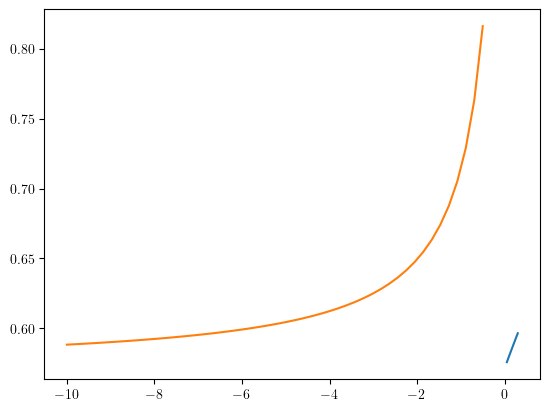

In [ ]:
meff=[]
TCrange=np.linspace(0.05,0.3,50)

for TC in TCrange:
    parameters["TC"]=TC
    parameters["TV"]=-10
    parameters["TH"]=TH_from_TV_TC(parameters["TV"],parameters["TC"],parameters["e_l"]*parameters["e_C_factor"],parameters["e_l"])
    meff.append(machine_efficiency(parameters))
plt.plot(TCrange,meff)


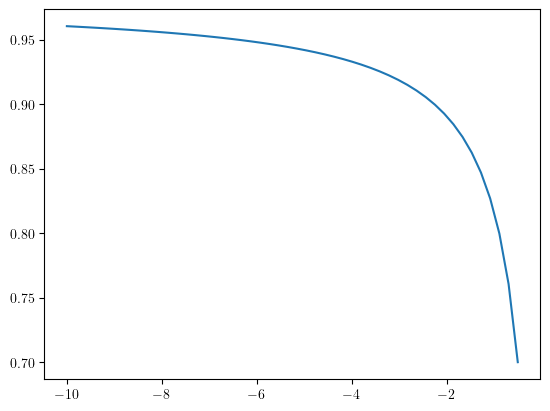

In [12]:
meff_TV=[]
TVrange=np.linspace(-10,-0.5,50)
for TV in TVrange:
    parameters["TV"]=TV
    parameters["TC"]=0.2
    parameters["TH"]=10
    meff_TV.append(machine_efficiency(parameters))

plt.plot(TVrange,meff_TV)

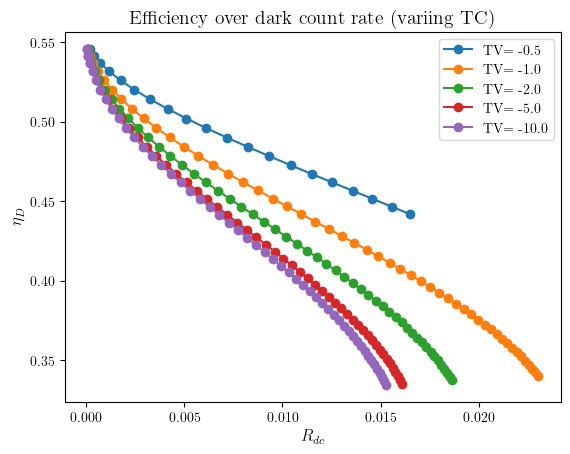

In [62]:
fig, ax = plt.subplots()
ax.set_xlabel("$R_{dc}$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

[plt.plot(dat_list[dat_list["TV"]==TV]["dark count rate"].values,
          dat_list[dat_list["TV"]==TV]["efficiency"].values,
          marker="o",
          label=f"TV= {dat_list[dat_list['TV']==TV]['TV'].values[0]}")
            for TV in [-0.5,-1,-2,-5,-10]]

plt.title("Efficiency over dark count rate (variing TC)")

plt.legend()

dat_list.reset_index(drop=True, inplace=True)
dat_list.to_csv("effic_over_jitter_plot.csv",index=False)

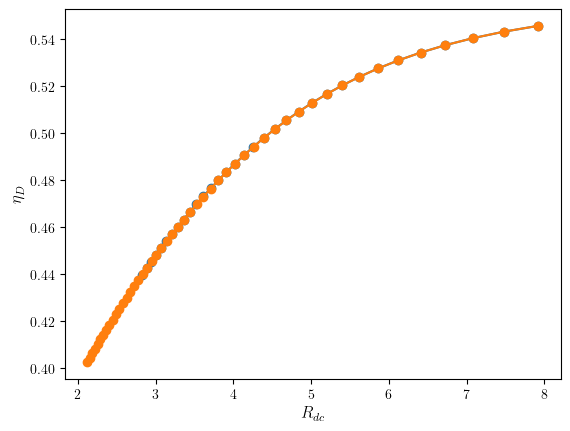

In [64]:
fig, ax = plt.subplots()
ax.set_xlabel("$R_{dc}$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')


plt.plot(dat1["entropy production"].values,dat1["efficiency"].values,marker="o")
plt.plot(dat2["entropy production"].values,dat2["efficiency"].values,marker="o")

In [36]:
print(parameters)

{'d_l': 3, 'e_max': 1, 'e_s': 0.1, 'TH': 10, 'TC': 0.05, 'g_sl': 1, 'g_ml': 1, 'e_C': 1.47, 'e_C_factor': 0.3, 't_f': 3000, 't_steps': 3000, 'rateM': 1, 'rateD': 10, 'rateB': 0.8, 'Tb': 0.1, 'Td': 0.1, 'k': 1, 'e_l': 4.9, 'TV': -1}


In [41]:
overplot=qload("effic_vs_TC_plot_overleaf")

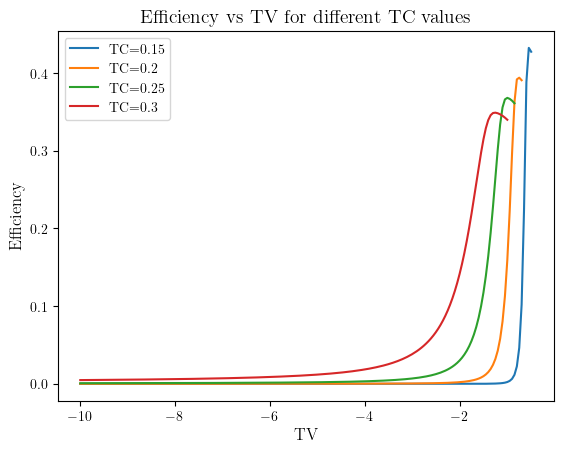

In [64]:
for plot in overplot:
    plt.plot(np.array(plot)[:, out_index("TV")], np.array(plot)[:, out_index("efficiency")], label=f'TC={np.array(plot)[-1, out_index("TC")]}')

plt.xlabel('TV')
plt.ylabel('Efficiency')
plt.title('Efficiency vs TV for different TC values')
plt.legend()
plt.show()


In [ ]:
dat_list=pd.DataFrame()
parameters["e_max"]=5
parameters["e_C_factor"]=0.5
for TC in [0.5,0.8,1,2,3]:
    parameters["TC"]=TC

    dat_list=pd.concat([dat_list,L_get_FoM_vari_one_parameter(parameters,"TV",np.linspace(-100,-0.001,200))])

In [74]:
dat_list

,efficiency,dark count rate,jitter,entropy production,entropy rate,d_l,e_max,e_s,TH,TC,...,t_f,t_steps,rateM,rateD,rateB,Tb,Td,k,e_l,TV
0,6.981328,1.025551e-24,1.681510e+21,316.410886,9.299825e-24,3,5,0.1,0.051282,0.2,...,3000,3000,1,10,0.8,0.2,0.2,1,4.9,-10.000
0,6.981328,1.025551e-24,1.681510e+21,316.410886,9.299825e-24,3,5,0.1,0.051295,0.2,...,3000,3000,1,10,0.8,0.2,0.2,1,4.9,-9.899
0,6.981328,1.025551e-24,1.681510e+21,316.410886,9.299825e-24,3,5,0.1,0.051309,0.2,...,3000,3000,1,10,0.8,0.2,0.2,1,4.9,-9.798
0,6.981328,1.025551e-24,1.681510e+21,316.410886,9.299825e-24,3,5,0.1,0.051323,0.2,...,3000,3000,1,10,0.8,0.2,0.2,1,4.9,-9.697
0,6.981328,1.025551e-24,1.681510e+21,316.410886,9.299825e-24,3,5,0.1,0.051337,0.2,...,3000,3000,1,10,0.8,0.2,0.2,1,4.9,-9.596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.408925,1.151507e-02,8.696244e+02,0.913684,1.950036e-02,3,5,0.1,3.406977,2.0,...,3000,3000,1,10,0.8,2.0,2.0,1,4.9,-2.930
0,0.435930,1.872165e-02,6.509547e+02,0.975119,3.170444e-02,3,5,0.1,4.299392,2.0,...,3000,3000,1,10,0.8,2.0,2.0,1,4.9,-2.829
0,0.459489,3.029622e-02,4.635044e+02,1.028477,5.130557e-02,3,5,0.1,5.982456,2.0,...,3000,3000,1,10,0.8,2.0,2.0,1,4.9,-2.728
0,0.478052,4.765901e-02,3.234793e+02,1.069969,8.070882e-02,3,5,0.1,10.342520,2.0,...,3000,3000,1,10,0.8,2.0,2.0,1,4.9,-2.627


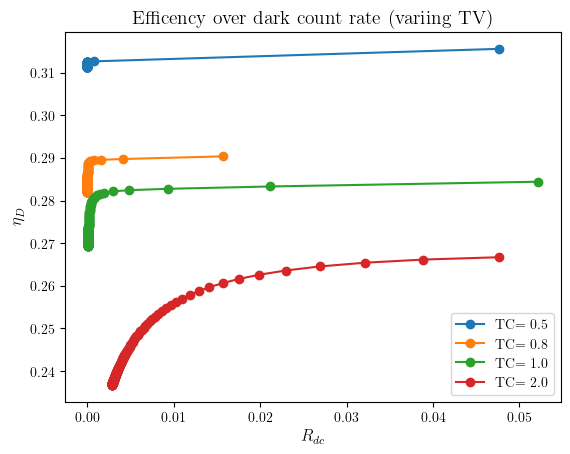

In [27]:


fig, ax = plt.subplots()
ax.set_xlabel("$R_{dc}$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

[plt.plot(dat_list[dat_list["TC"]==TC]["dark count rate"].values,
          dat_list[dat_list["TC"]==TC]["efficiency"].values,
          marker="o",
          label=f"TC= {dat_list[dat_list['TC']==TC]['TC'].values[0]}")
            for TC in [0.5,0.8,1,2]]
plt.title("Efficency over dark count rate (variing TV)")

plt.legend()

# dat_list.reset_index(drop=True, inplace=True)
# dat_list.to_csv("effic_over_jitter_plot.csv",index=False)

In [5]:
plot_list_3=[]
parameters["TC"]=0.05
parameters["g_ml"]=1
parameters["e_max"]=1
for TC in [0.05,0.1,0.2]:
    parameters["TC"]=TC
    plot=L_get_FoM_vari_one_parameter(parameters,"TV",np.linspace(-10,0,50))
    plot_list_3.append(plot)


/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/autonomous_activated_amplification/FigOMerit_functions.py:355: RuntimeWarning: divide by zero encountered in scalar divide
  return((e_L-e_C)/(e_L/TV+e_C/TC))
/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/autonomous_activated_amplification/Hamiltonians.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  RH_pl=np.sqrt(rateM*np.exp(-1/TH*(e_c+e_l))/(1+np.exp(-1/TH*(e_c+e_l))))
/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/autonomous_activated_amplification/Hamiltonians.py:49: RuntimeWarning: divide by zero encountered in scalar divide
  RH_mi=np.sqrt(rateM*1/(1+np.exp(-1/TH*(e_c+e_l))))
/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/autonomous_activated_amplification/Hamiltonians.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  RH_pl=np.s

In [3]:
dat_list=pd.DataFrame()
parameters["e_max"]=1
parameters["e_l"]=(parameters["e_max"]-parameters["e_s"])/(parameters["d_l"]-2)
parameters["TC"]=0.2
for TV in  [-0.5,-1,-5,-10]:
    parameters["TV"]=TV
    min_eC=-parameters["e_l"]*parameters["TC"]/TV
    dat_list=pd.concat([dat_list,L_get_FoM_vari_one_parameter(parameters,"e_C_factor",np.linspace(min_eC,1,100))])


TV:  -0.5
TC:  0.2
TH:  22.64615384615359
TV:  -0.5
TC:  0.2
TH:  10.041379310344825
TV:  -0.5
TC:  0.2
TH:  6.400000000000003
TV:  -0.5
TC:  0.2
TH:  4.668852459016397
TV:  -0.5
TC:  0.2
TH:  3.6571428571428597
TV:  -0.5
TC:  0.2
TH:  2.9935483870967725
TV:  -0.5
TC:  0.2
TH:  2.524770642201834
TV:  -0.5
TC:  0.2
TH:  2.1759999999999997
TV:  -0.5
TC:  0.2
TH:  1.9063829787234026
TV:  -0.5
TC:  0.2
TH:  1.6917197452229302
TV:  -0.5
TC:  0.2
TH:  1.516763005780346
TV:  -0.5
TC:  0.2
TH:  1.3714285714285719
TV:  -0.5
TC:  0.2
TH:  1.2487804878048778
TV:  -0.5
TC:  0.2
TH:  1.1438914027149327
TV:  -0.5
TC:  0.2
TH:  1.0531645569620252
TV:  -0.5
TC:  0.2
TH:  0.9739130434782615
TV:  -0.5
TC:  0.2
TH:  0.9040892193308542
TV:  -0.5
TC:  0.2
TH:  0.8421052631578954
TV:  -0.5
TC:  0.2
TH:  0.786710963455149
TV:  -0.5
TC:  0.2
TH:  0.7369085173501576
TV:  -0.5
TC:  0.2
TH:  0.6918918918918922
TV:  -0.5
TC:  0.2
TH:  0.6510028653295129
TV:  -0.5
TC:  0.2
TH:  0.6136986301369866
TV:  -0.5
TC:  0.

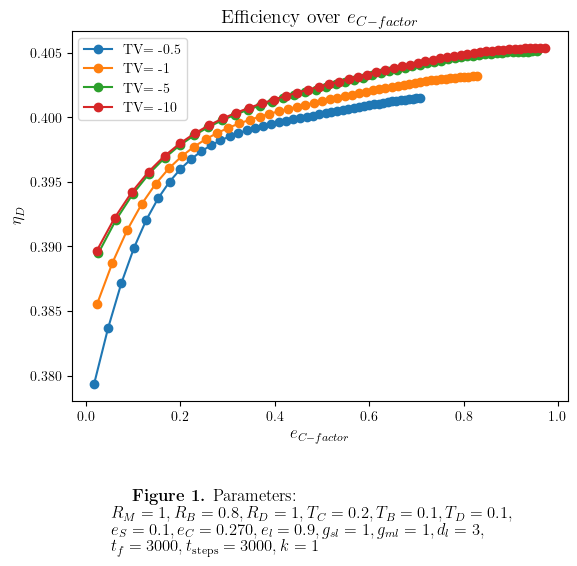

In [6]:
fig, ax = plt.subplots()
ax.set_xlabel("$e_{C-factor}$")
ax.set_ylabel("$\eta_D$")

[plt.plot(dat_list[dat_list["TV"]==TV]["machine_efficiency"].values,
          dat_list[dat_list["TV"]==TV]["efficiency"].values,
          marker="o",label=f"TV= {TV}")
          for TV in [-0.5,-1,-5,-10]]

plt.title("Efficiency over $e_{C-factor}$")

caption = ( r"\textbf{Figure 1.} Parameters: \\"
            fr"$R_M={parameters['rateM']}, R_B={parameters['rateB']}, R_D={parameters['rateD']}, T_C={parameters['TC']}, T_B={parameters['Tb']}, T_D={parameters['Td']},$ \\"
            r"\quad "
            fr"$e_S={parameters['e_s']}, e_C={parameters['e_C']:.3f}, e_l={parameters['e_l']}, g_{{sl}}={parameters['g_sl']}, g_{{ml}}={parameters['g_ml']}, d_l={parameters['d_l']},$ \\"
            fr"$t_f={parameters['t_f']}, t_{{\mathrm{{steps}}}}={parameters['t_steps']}, k={parameters['k']}$"
          )

plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.legend()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


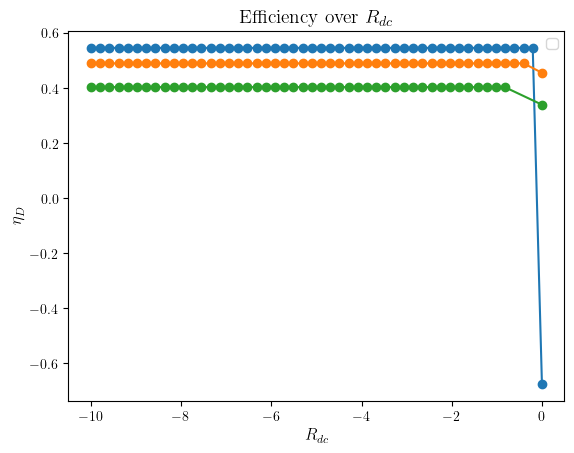

In [8]:
fig, ax = plt.subplots()
ax.set_xlabel("$R_{dc}$")
ax.set_ylabel("$\eta_D$")

[plt.plot(plot["TV"].values,plot["efficiency"].values,marker="o") for plot in plot_list_3]

# ax.set_yscale('log')
# ax.set_xscale('log')
# plt.xlim(0,20)
plt.title("Efficiency over $R_{dc}$")

plt.legend()

In [4]:
plot_list_4=[]
parameters["g_ml"]=1
parameters["e_max"]=0.5
for TV in [-10,-5,-1,-0.1]:
    parameters["TV"]=TV
    plot=L_get_FoM_vari_one_parameter(parameters,"TC",np.linspace(0.01,0.5,50))
    if len(plot)!=0  :
        plot_list_4.append(plot)


KeyboardInterrupt: 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


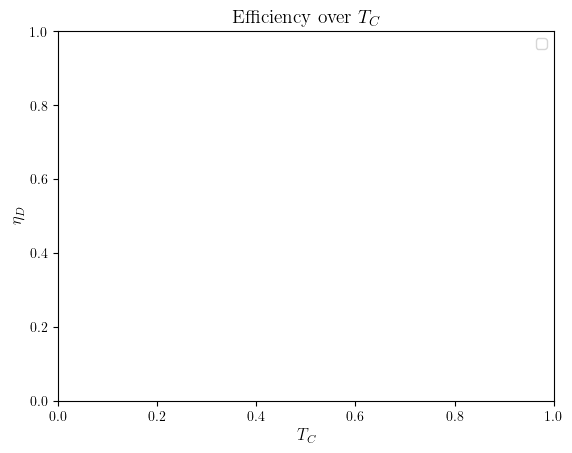

In [5]:
fig, ax = plt.subplots()
ax.set_xlabel("$T_C$")
ax.set_ylabel("$\eta_D$")

[plt.plot(plot["TC"].values,plot["efficiency"].values,marker="o",label=f"TV= {plot['TV'].values[0]}") for plot in plot_list_4]

# ax.set_yscale('log')
# ax.set_xscale('log')
# plt.xlim(0,20)
plt.title("Efficiency over $T_C$")

plt.legend()

In [ ]:
dat_list=pd.DataFrame()
parameters["e_l"]=(parameters["e_max"]-parameters["e_s"])/(parameters["d_l"]-2)
parameters["TC"]=0.2
for TV in  [-0.5,-1,-5,-10]:
    parameters["TV"]=TV
    min_eC=-parameters["e_l"]*parameters["TC"]/TV
    dat_list=pd.concat([dat_list,L_get_FoM_vari_one_parameter(parameters,"rateD",np.linspace(0.1,5,100))])

In [3]:
parameters["TV"]=-10
parampl=Parameter_plot(parameters,"TC",np.linspace(0.05,1,50))

for TV in [-0.5,-1,-2,-5,-10]:
    parameters["TV"]=TV
    parampl=pd.concat([parampl,Parameter_plot(parameters,"TC",np.linspace(0.05,1,50))])

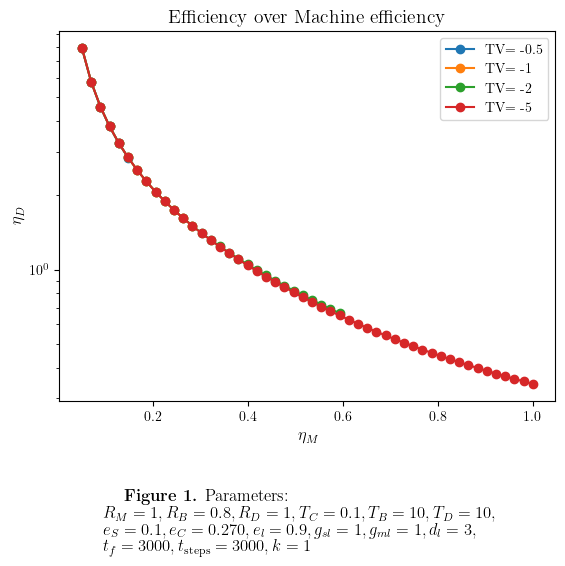

In [31]:
fig, ax = plt.subplots()
ax.set_xlabel("$\eta_M$")
ax.set_ylabel("$\eta_D$")
parameters["Tb"]=10
parameters["Td"]=10
[plt.plot(parampl[parampl["TV"]==TV]["TC"].values,
      parampl[parampl["TV"]==TV]["entropy production"].values,
      marker="o",label=f"TV= {TV}")
      for TV in [-0.5,-1,-2,-5]]


ax.set_yscale('log')
# ax.set_xscale('log')

plt.title("Efficiency over Machine efficiency")

caption = ( r"\textbf{Figure 1.} Parameters: \\"
      fr"$R_M={parameters['rateM']}, R_B={parameters['rateB']}, R_D={parameters['rateD']}, T_C={parameters['TC']}, T_B={parameters['Tb']}, T_D={parameters['Td']},$ \\"
      r"\quad "
      fr"$e_S={parameters['e_s']}, e_C={parameters['e_C']:.3f}, e_l={parameters['e_l']}, g_{{sl}}={parameters['g_sl']}, g_{{ml}}={parameters['g_ml']}, d_l={parameters['d_l']},$ \\"
      fr"$t_f={parameters['t_f']}, t_{{\mathrm{{steps}}}}={parameters['t_steps']}, k={parameters['k']}$"
      )

plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.legend()


# Plots in the Paper

## Argument for choosing $T_B=T_D=T_C$

The following plots show that both the efficiency decreases monotonically with the bath temperature $T_B$ and the detector temperature $T_D$. Thus choosing their temperature to be $T_C$ always means we are achieving the maximal efficiency with the given resources. Furthermore, there seems to be a special point when all these temperatures are equal, where the efficiency does not tepend on $T_V$ the virtual temperature.

If the two baths temperatures are bigger than $T_C$ (even if they are equal in temperature), the effect of the virtualmachine is bigger, as lower virtual temperature gives us better efficiency

In [ ]:
parameters={'d_l': 3, 'e_max': 1, 'e_s': 0.1, 'TH': 10, 'TC': 0.3, 'g_sl': 1, 'g_ml': 1, 'e_C': 0.27, 'e_C_factor': 0.3, 't_f': 3000, 't_steps': 3000, 'rateM': 1, 'rateD': 1, 'rateB': 0.8, 'Tb': 0.3, 'Td': 0.3, 'k': 1, 'Tb_indep_flag': True, 'Td_indep_flag': True, 'e_l': 0.9, 'TV': -10}
dat_list3=pd.DataFrame()
parameters["Tb_indep_flag"]=True
parameters["Td_indep_flag"]=True
parameters["Tb"]=0.3
parameters["TC"]=0.3
for TV in [-1,-2,-5,-10]:
    parameters["TV"]=TV
    dat_list3=pd.concat([dat_list3,Parameter_plot(parameters,"Td",np.linspace(0.1,1,50))])

# dat_list3.to_csv("eff_Td.csv", index=False)


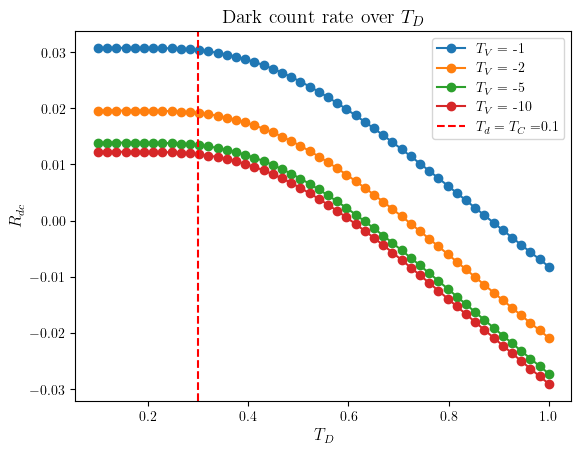

In [32]:
dat_list3 = pd.read_csv("eff_Td.csv")

fig, ax = plt.subplots()
ax.set_xlabel("$T_D$")
ax.set_ylabel("$R_{dc}$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)

[plt.plot(dat_list3[dat_list3["TV"]==TV]["Td"].values,
          dat_list3[dat_list3["TV"]==TV]["dark count rate"].values,
          marker="o",
          label=f"$T_V=$ {dat_list3[dat_list3['TV']==TV]['TV'].values[0]}")
            for TV in [-1,-2,-5,-10]]

plt.axvline(x=parameters["TC"], color='r', linestyle='--', label=f'$T_d=T_C=${parameters["Tb"]}')

plt.title("Dark count rate over $T_D$")

plt.legend()

In [ ]:
dat_list4=pd.DataFrame()
parameters["Tb_indep_flag"]=True
parameters["Td_indep_flag"]=True
parameters["Td"]=0.3
parameters["TC"]=0.3
for TV in [-1,-2,-5,-10]:
    parameters["TV"]=TV
    dat_list4=pd.concat([dat_list4,Parameter_plot(parameters,"Tb",np.linspace(0.1,1,50))])

# dat_list4.to_csv("eff_Td.csv", index=False)

In [32]:
dat_list4.to_csv("eff_Tb.csv", index=False)


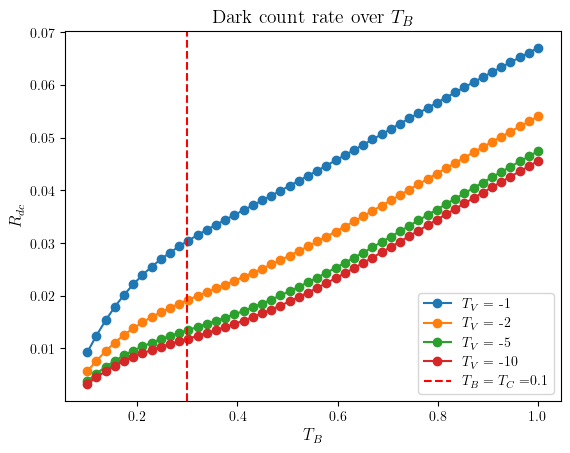

In [34]:
dat_list4 = pd.read_csv("eff_Tb.csv")


fig, ax = plt.subplots()
ax.set_xlabel("$T_B$")
ax.set_ylabel("$R_{dc}$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)

[plt.plot(dat_list4[dat_list4["TV"]==TV]["Tb"].values,
          dat_list4[dat_list4["TV"]==TV]["dark count rate"].values,
          marker="o",
          label=f"$T_V=$ {dat_list4[dat_list4['TV']==TV]['TV'].values[0]}")
            for TV in [-1,-2,-5,-10]]

plt.axvline(x=parameters["TC"], color='r', linestyle='--', label=f'$T_B=T_C=${parameters["Td"]}')


plt.title("Dark count rate over $T_B$")

plt.legend()

In [43]:
dat_list4=pd.DataFrame()
parameters["Tb_indep_flag"]=True
parameters["Td_indep_flag"]=True
parameters["Td_eq_Tb_flag"]=True
parameters["TC"]=0.6
for TV in [-1,-2,-5,-10]:
    parameters["TV"]=TV
    dat_list4=pd.concat([dat_list4,Parameter_plot(parameters,"Td",np.linspace(0.1,1,50))])

# dat_list4.to_csv("eff_Td_eq_Tb.csv", index=False)


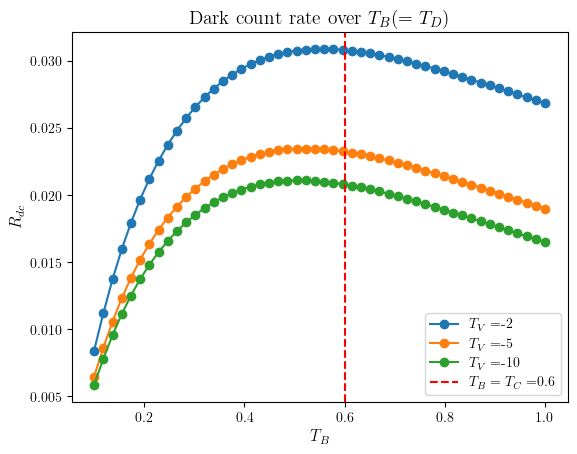

In [45]:
# dat_list4 = pd.read_csv("eff_Td_eq_Tb.csv")


fig, ax = plt.subplots()
ax.set_xlabel("$T_B$")
ax.set_ylabel("$R_{dc}$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)

[plt.plot(dat_list4[dat_list4["TV"]==TV]["Tb"].values,
          dat_list4[dat_list4["TV"]==TV]["dark count rate"].values,
          marker="o",
          label=f"$T_V= ${dat_list4[dat_list4['TV']==TV]['TV'].values[0]}")
            for TV in [-2,-5,-10]]

plt.axvline(x=parameters["TC"], color='r', linestyle='--', label=f'$T_B=T_C=${parameters["TC"]}')


plt.title("Dark count rate over $T_B(=T_D)$")

plt.legend()

## Efficiency-$\Delta t_D$ trade-off variing rate D?

In [ ]:
dat_list4=pd.DataFrame()
parameters["Tb_indep_flag"]=False
parameters["Td_indep_flag"]=False
parameters["Td_eq_Tb_flag"]=False
parameters["Max_TV_flag"]=True
parameters["epsilon"]=10**(-7)

parameters["g_ml"]=1
parameters["g_sl"]=1
parameters["rateM"]=1

for RD_gsl in [[],0.5,1,1.5,2]:
    parameters["rateD"]=rateD
    dat_list4=pd.concat([dat_list4,Parameter_plot(parameters,"TC",np.logspace(-2,0.3,50))])

dat_list4.to_csv("param_TC_vari_rateD_v1.csv", index=False)

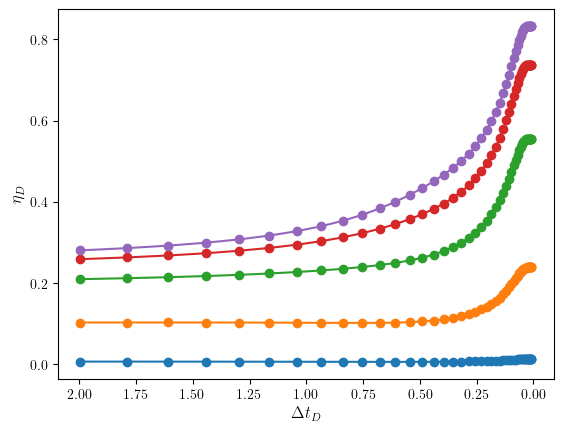

In [195]:
dat_list4 = pd.read_csv("param_TC_vari_rateD_v1.csv")


fig, ax = plt.subplots()
ax.set_xlabel("$\Delta t_D$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# plt.xlim(6,10)

plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)
[plt.plot(dat_list4[dat_list4["rateD"]==rateD]["TC"].values,
      dat_list4[dat_list4["rateD"]==rateD]["efficiency"].values,
      marker="o",
      label=f"$rateD= ${dat_list4[dat_list4['rateD']==rateD]['rateD'].values[0]}")
      for rateD in [0.1, 0.5, 1, 1.5, 2]]

plot = plt.gcf()

# plt.axvline(x=parameters["TC"], color='r', linestyle='--', label=f'$T_B=T_C=${parameters["TC"]}')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


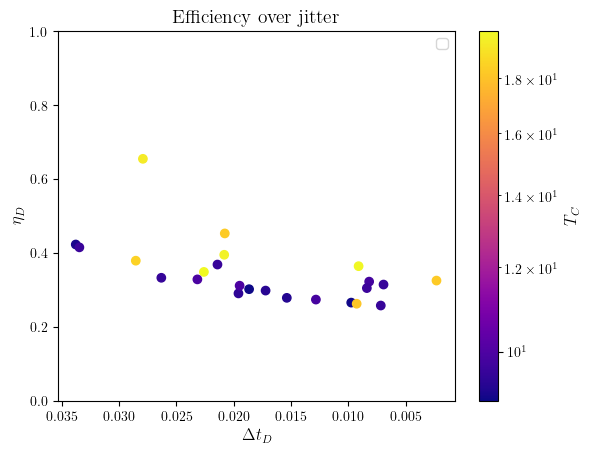

In [552]:
dat_list4 = pd.read_csv("param_TC_vari_rateD_v1.csv")


fig, ax = plt.subplots()
ax.set_xlabel("$\Delta t_D$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')

# ax.set_xscale('log')

plt.ylim(0,1)

plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)


# [plt.plot(dat_list4[dat_list4["rateD"]==rateD]["jitter"].values,
#       dat_list4[dat_list4["rateD"]==rateD]["efficiency"].values,
#       marker="o",
#       label=f"$rateD= ${dat_list4[dat_list4['rateD']==rateD]['rateD'].values[0]}")
#       for rateD in [0.1, 0.5, 1,2]]

plot = plt.gcf()

# plt.axvline(x=parameters["TC"], color='r', linestyle='--', label=f'$T_B=T_C=${parameters["TC"]}')



############################################################################################################
dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v2")
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v1")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_v5")])
condition = dset["k"] == 1


# condition &= ((dset["TV"] > -4.9)& (dset["TV"] < -4.8))
# condition &= dset["TV"] >-1
# condition &= dset["TC"] > 0.01


# condition &= dset["TC"] <2
condition &= dset["TC"] > 0.1


# condition &= dset["g_ml"] > 9
condition &= dset["efficiency"] < 1
condition &= dset["efficiency"] > 0
# condition &= dset["efficiency"] > 0.1
# condition &= dset["jitter"] > 1 # Here I am excluding a wrong datapoint (I doublechecked)
# condition &= (((dset["jitter"] <2 ) & (dset["jitter"] >1.9))) |(((dset["jitter"] <20)  & (dset["jitter"] >19))) |(((dset["jitter"] <1000)  & (dset["jitter"] >900)))

jval=10
condition &= ((dset["jitter"] <jval ) & (dset["jitter"] >jval*(1-0.1))) | ((dset["jitter"] <jval*2 ) & (dset["jitter"] >2*jval*(1-0.1)))

# condition &= dset["rateD"]*dset["g_sl"] < 3
condition &= dset["rateD"] <2
condition &= dset["rateD"] >1.9
condition &= dset["g_sl"] < 2
condition &= dset["g_ml"] < 2

# condition &= dset["g_sl"] > 1
# condition &= dset["g_ml"] > 1




# condition &= ((dset["entropy production"] < 0.2) &  (dset["entropy production"] > 0.199)) | (dset["entropy production"] < 0.1) &  (dset["entropy production"] > 0.099)
# condition &= dset["entropy production"] > 0.199


# condition &= dset["entropy production"] < 0.11
# condition &= dset["entropy production"] > 0.1

# condition &= dset["entropy production"] < 2.1
# condition &= dset["entropy production"] > 2

dset=dset[condition]

scatter=plt.scatter(dset["dark count rate"].values,
                    dset["efficiency"].values,
                    # c=dset["rateD"].values*dset["g_sl"].values,
                    c=dset["jitter"].values,
                    cmap='plasma',
                    norm=mcolor.LogNorm())

############################################################################################################

plt.colorbar(scatter, label="$T_C$")
plt.legend()

plt.title("Efficiency over jitter")

plt.legend()

In [169]:
# Calculate the L efficiency function of the parameters according to dset
params = dset.iloc[0]
parameters.update({
    "TC": params["TC"],
    "TV": params["TV"],
    "g_ml": params["g_ml"],
    "rateD": params["rateD"],
    "Tb": params["Tb"],
    "Td": params["Td"],
    "TH": params["TH"],
    "e_C": params["e_C"],
    "e_C_factor": params["e_C_factor"],
    "e_max": params["e_max"],
    "e_s": params["e_s"],
    "d_l": params["d_l"],
    "rateM": params["rateM"],
    "rateB": params["rateB"],
    "t_f": params["t_f"],
    "t_steps": params["t_steps"],
    "k": params["k"],
    "Tb_indep_flag": params["Tb_indep_flag"],
    "Td_indep_flag": params["Td_indep_flag"],
    "Td_eq_Tb_flag": params["Td_eq_Tb_flag"],
    "Max_TV_flag": params["Max_TV_flag"],
    "epsilon": params["epsilon"],
    "e_l": params["e_l"]
})
L,DI,init,steady = get_L_Draz_Init_Steady(parameters)
efficiency = L_efficiency(DI,init,get_e_ops(parameters),parameters)
jitter=L_jitter(DI,init,get_e_ops(parameters),parameters)
print(f"L efficiency: {efficiency}")
print(f"jitter: {jitter}")

L efficiency: 0.629638325888547
jitter: 6.100234074547073


#### Efficiency over entropy production

In [10]:
dat_list4=pd.DataFrame()
parameters["Tb_indep_flag"]=False
parameters["Td_indep_flag"]=False
parameters["Td_eq_Tb_flag"]=False
parameters["Max_TV_flag"]=True
parameters["epsilon"]=10**(-5)
TC_values = np.logspace(np.log10(0.001), np.log10(5), 50)
parameters["g_ml"]=2
for rateD in [0.5, 1, 2]:
    parameters["rateD"] = rateD
    dat_list4 = pd.concat([dat_list4, Parameter_plot(parameters, "TC", TC_values)])

dat_list4.to_csv("param_TC_vari_rateD_v1.csv", index=False)

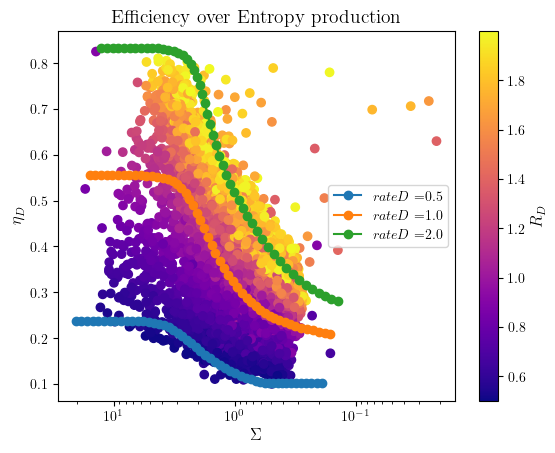

In [342]:
dat_list4 = pd.read_csv("param_TC_vari_rateD_v1.csv")


fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma$")
ax.set_ylabel("$\eta_D$")

# ax.set_yscale('log')
ax.set_xscale('log')

plt.gca().invert_xaxis()

# ax.set_ylim(0, 1)
[plt.plot(dat_list4[dat_list4["rateD"]==rateD]["entropy production"].values,
      dat_list4[dat_list4["rateD"]==rateD]["efficiency"].values,
      marker="o",
      label=f"$rateD= ${dat_list4[dat_list4['rateD']==rateD]['rateD'].values[0]}")
      for rateD in [0.5, 1, 2]]

plot = plt.gcf()

# plt.axvline(x=parameters["TC"], color='r', linestyle='--', label=f'$T_B=T_C=${parameters["TC"]}')



############################################################################################################

dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_v5")])
condition = dset["k"] == 1


# condition &= ((dset["TV"] > -4.9)& (dset["TV"] < -4.8))
# condition &= dset["TV"] < -4.8
# condition &= dset["TV"] > -6
# condition &= dset["TC"] < 0.7
# condition &= dset["g_ml"] <=4
condition &= dset["efficiency"] < 1
# condition &= dset["efficiency"] > 0.8
condition &= dset["entropy production"] > 0

# condition &= dset["rateD"] <2
# condition &= dset["rateD"] > 0.5

# condition &= dset["g_ml"] < 2
# condition &= dset["g_ml"] > 0.5

# condition &= dset["entropy production"] < 200
# condition &= dset["entropy production"] > 0

dset=dset[condition]

scatter=plt.scatter(dset["entropy production"].values,
                    dset["efficiency"].values,
                    c=dset["rateD"].values, cmap='plasma')

############################################################################################################

plt.colorbar(scatter, label="$R_D$")
plt.legend()

plt.title("Efficiency over Entropy production")

plt.legend()


#### Dark count rate - Jitter trade-off for minimal efficiency

In [ ]:
dat_list4=pd.DataFrame()
parameters["Tb_indep_flag"]=False
parameters["Td_indep_flag"]=False
parameters["Td_eq_Tb_flag"]=False
parameters["Max_TV_flag"]=True
parameters["epsilon"]=10**(-7)
TC_values = np.logspace(np.log10(0.005), np.log10(5), 50)
parameters["g_ml"]=2
for rateD in [0.5, 1, 2]:
    parameters["rateD"] = rateD
    dat_list4 = pd.concat([dat_list4, Parameter_plot(parameters, "TC", TC_values)])

dat_list4.to_csv("param_TC_vari_rateD_v1.csv", index=False)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


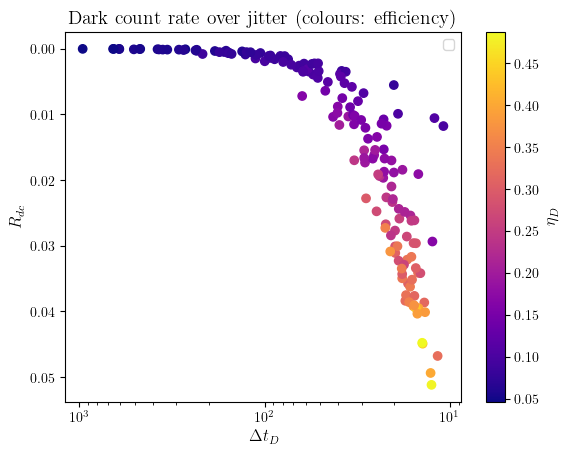

In [43]:
dat_list4 = pd.read_csv("param_TC_vari_rateD_v1.csv")


fig, ax = plt.subplots()
ax.set_xlabel("$\Delta t_D$")
ax.set_ylabel("$R_{dc}$")

# ax.set_yscale('log')
ax.set_xscale('log')



# ax.set_ylim(0, 1)
# [plt.plot(dat_list4[dat_list4["rateD"]==rateD]["jitter"].values,
#       dat_list4[dat_list4["rateD"]==rateD]["dark count rate"].values,
#       marker="o",
#       label=f"$rateD= ${dat_list4[dat_list4['rateD']==rateD]['rateD'].values[0]}")
#       for rateD in [0.5, 1, 2]]

plot = plt.gcf()

# plt.axvline(x=parameters["TC"], color='r', linestyle='--', label=f'$T_B=T_C=${parameters["TC"]}')



############################################################################################################

dset= pd.read_csv("FOM_Dinv_exact_v5")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_MaxTV_v1")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.5
condition &= dset["efficiency"] <1
# condition &= dset["rateD"] >15
# condition &= dset["rateD"] <0.8
# condition &= dset["g_ml"] >10
# condition &= dset["g_ml"] <12

# condition &= dset["TC"] >0.6
condition &= dset["TC"] <1
# condition &= dset["TV"] <-3
# condition &= dset["TV"] >-4
# condition &= dset["TH"] >dset["TC"]*(dset["e_l"]+dset["e_C"])/dset["e_C"]

# condition &= dset["TV"] < -5
# condition &= dset["g_ml"] <1

# condition &=  ((dset["jitter"] < 7) | ((dset["jitter"] < 10) & (dset["jitter"] > 9)) | ((dset["jitter"] < 15) & (dset["jitter"] > 14)))


# condition &= dset["entropy production"] >0.0
# condition &= dset["entropy production"] <0.1
# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000



condition &= dset["rateD"]<2
condition &= dset["rateD"]>0.5

condition &= dset["g_ml"]<2
condition &= dset["g_ml"]>0.5

condition &= dset["jitter"]<1000

# condition &= dset["entropy rate"] >0
# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000


# condition &= dset["g_ml"] <1

# condition &= (dset["rateD"] <0.5 or dset["rateD"] >5)


dset=dset[condition]

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

# ax.set_yscale('log')
ax.set_xscale('log')

plt.title("Efficiency over dark count rate (colour: jitter)")
scatter=plt.scatter(dset["jitter"].values,
                    dset["dark count rate"].values
                ,c=dset["TC"].values,cmap='plasma'
                )


plt.colorbar(scatter, label="$\eta_D$")
plt.legend()

plt.title("Dark count rate over jitter (colours: efficiency)")

plt.legend()

#### Investigating the first gap

effic 4.950086852713095e-07
analyt effic:  0.0009990009990009992


/home/manu/MEGA/Meine_Uni/Uni/Apollaro_Group/Projects/01-Thermodynamics_of_Precision/Python_Code/Jupyter_Notebooks/qutip503env/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


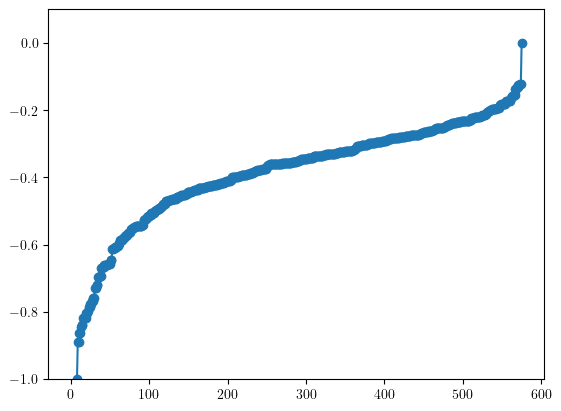

In [ ]:
parameters["TC"] = 2  # Set to a small positive value
parameters["TH"] = np.inf  # Set to a large positive value
parameters["rateM"]=1
parameters["rateD"]=0.001
parameters["rateB"]=1

plt.ylim(-1, 0.1)

L, DI, init, steady = get_L_Draz_Init_Steady(parameters)
print("effic",L_efficiency(DI,init,get_e_ops(parameters),parameters))
print("analyt effic: ",parameters["rateD"]/(parameters["rateB"]+parameters["rateD"]))
plt.plot(DI.eigenenergies(),marker="o")
# c_ops_k(parameters["rateM"],
# 	parameters["rateB"], parameters["rateD"], parameters["TH"], parameters["TC"],
# 	parameters["Tb"], parameters["Td"], parameters["e_s"], parameters["e_C"],
# 	parameters["e_l"], parameters["d_l"], parameters["k"],
# )

# print(steady.ptrace([2]))


In [ ]:
parameters["TC"] = 0.2  # Set to a small positive value
parameters["TH"] = 10  # Set to a large positive value
parameters["rateM"]=1
parameters["rateD"]=1
parameters["rateB"]=1

eigen_en_list=[]
first_gap_list=[]
last_gap_list=[]
foms=pd.DataFrame()
rd_range=np.linspace(0.01,2,30)
for rateD in rd_range:
    parameters["rateD"] = rateD
    L, DI, init, steady = get_L_Draz_Init_Steady(parameters)
    eigenen=np.sort(np.array(L.eigenenergies()))
    foms=pd.concat([foms,L_get_all_figures_of_merit(DI,init,steady,get_e_ops(parameters),parameters,L)])
    eigen_en_list.append(eigenen)
    last_gap_list.append(eigenen[-1]-eigenen[0])
    first_gap_list.append(eigenen[1]-eigenen[0])

In [16]:
L, DI, init, steady = get_L_Draz_Init_Steady(parameters)

In [39]:
2*2*2

8

In [80]:
24*2

48

In [ ]:
parameters["TC"] = 0  # Set to a small positive value
parameters["TH"] = np.inf  # Set to a large positive value
parameters["rateM"]=1
parameters["rateD"]=2
parameters["rateB"]=1

L, DI, init, steady = get_L_Draz_Init_Steady(parameters)
cops=c_ops_k(
    parameters["rateM"], parameters["rateB"], parameters["rateD"], parameters["TH"],
    parameters["TC"], parameters["Tb"], parameters["Td"], parameters["e_s"],
    parameters["e_C"], parameters["e_l"], parameters["d_l"], parameters["k"]
)
JD = cops[0].dag()*cops[0]-cops[1].dag()*cops[1]
JD_super = qutip.spre(JD) - qutip.spost(JD.dag())
result = propagator(L,1)*init
non_zero_elements = (abs(result.full()) > 10**-10).sum()
print(f"Number of non-zero elements (or elements smaller than 10**-8): {non_zero_elements}")

Number of non-zero elements (or elements smaller than 10**-8): 48


In [217]:
operator_to_vector(identity([2,2,3,2])).dag()*JD_super*result

0j

In [218]:
(JD*vector_to_operator(result)).tr()

(-0.07795307336756822-1.5798644075051544e-35j)

In [126]:
# print(vector_to_operator(init))
k=0
l=0
count=0
for i in steady:
    l=0
    for j in i:
        if abs(j) >10**-4:
            print(j,"lk:",l,k)
            count+=1
        l+=1
    k+=1
print("count",count)

(0.4838709677419352+0j) lk: 0 0
(0.06451612903225805+0j) lk: 2 2
(0.22580645161290316+0j) lk: 6 6
(3.610588608259379e-19+0.09677419354838708j) lk: 14 6
(0.03225806451612904+0j) lk: 8 8
(0.06451612903225803+0j) lk: 12 12
(3.610588608259379e-19-0.09677419354838708j) lk: 6 14
(0.08064516129032256+0j) lk: 14 14
(0.032258064516129024+0j) lk: 18 18
(0.016129032258064516+0j) lk: 20 20
count 10


In [221]:
Leigenstates=L.dag().eigenstates()
Reigenstates=L.eigenstates()

In [ ]:
eigsys=[]
for j in range(len(Leigenstates[1])):
    for i in range(len(Leigenstates[1])):
        val= Leigenstates[1][j].dag()*Reigenstates[1][i]
        if (np.real(val) > 10**-6) and (Leigenstates[0][j]==Reigenstates[0][i]):
            print(val)
            print(Leigenstates[0][j],Reigenstates[0][i])
            eigsys.append([Leigenstates[1][j].dag(),Reigenstates[1][i]])


In [258]:
eigsys

[]

In [261]:
[Leigenstates[1][200].dag()*Reigenstates[1][i] for i in range(len(Leigenstates[1]))][np.abs(Leigenstates[1][200].dag()*Reigenstates[1][i])==0]

/tmp/ipykernel_20963/2607788334.py:1: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  [Leigenstates[1][200].dag()*Reigenstates[1][i] for i in range(len(Leigenstates[1]))][np.abs(Leigenstates[1][200].dag()*Reigenstates[1][i])==0]


0j

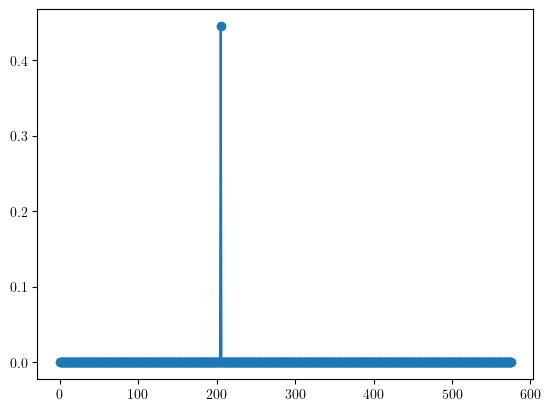

In [253]:
plt.plot([Leigenstates[1][200].dag()*Reigenstates[1][i] for i in range(len(Leigenstates[1]))],marker="o")

In [ ]:


# print(Leigenstates[0][-2],Leigenstates[1][-2])
overlap=[]
for es in Leigenstates[1]:
    overlap.append(es.dag()*init)

print(Leigenstates[0][-10:-1])
print(overlap[-10:-1])

[-0.53663022+9.00000000e-01j -0.53663022-9.00000000e-01j
 -0.53663022+2.70000000e-01j -0.53663022-2.70000000e-01j
 -0.53314152-8.00000000e-01j -0.53314152+8.00000000e-01j
 -0.0926487 +7.56331287e-16j -0.05944164-1.00000000e-01j
 -0.05944164+1.00000000e-01j]
[(-2.0083873532107004e-16-6.913726117164735e-17j), (-1.706100722848093e-16-2.8259471243357432e-16j), (-6.841982673503886e-17-8.209357156923875e-16j), (-4.982287682341654e-16+1.1809776957303687e-16j), (0.020684870032600344-0.007662194338378673j), (0.020684870032600396+0.007662194338378463j), (0.29437141677702866-1.6770858895169334e-16j), (3.9598786053887424e-17-1.662828968979991e-17j), (-1.062754426536697e-15-2.9922318544328293e-15j)]


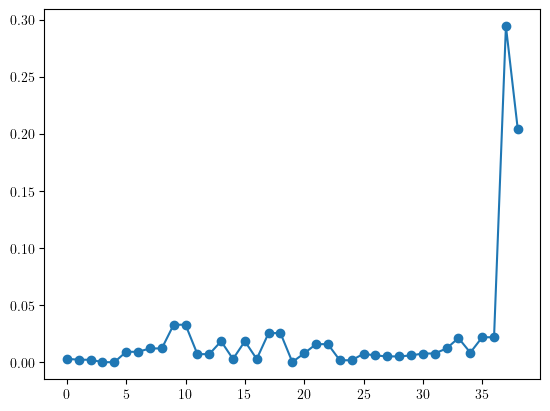

In [220]:
overlapbiggerz=[]
for x in overlap:
    if np.abs(x)>10**-6:
        overlapbiggerz.append(x)
plt.plot(np.abs(overlapbiggerz),marker="o")
# plt.plot(np.real(Leigenstates[0][-20:-1]),marker="o",color="red")
# plt.plot(np.imag(Leigenstates[0][-20:-1]),marker="o",color="green")


In [199]:
overlap[-5:-1]

[(0.020684870032600396+0.007662194338378463j),
 (0.29437141677702866-1.6770858895169334e-16j),
 (3.9598786053887424e-17-1.662828968979991e-17j),
 (-1.062754426536697e-15-2.9922318544328293e-15j)]

In [202]:
print(overlap[-5:-1][1])
print(Leigenstates[0][-5:-1][1])

(0.29437141677702866-1.6770858895169334e-16j)
(-0.09264869964814128+7.563312869064859e-16j)


In [184]:
import numpy as np

# Define the value you are looking for
value_to_find = 0.20412414523194053 - 9.002368402530265e-16j

# Convert overlap to a numpy array for easier comparison
overlap_array = np.array(overlap)

# Find the index where overlap is equal to the specified value
index = np.where(overlap == overlapbiggerz[-3])[0]

print(f"Index where overlap is equal to {value_to_find}: {index}")

Index where overlap is equal to (0.20412414523194053-9.002368402530265e-16j): []


/tmp/ipykernel_20963/1773543057.py:10: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  index = np.where(overlap == overlapbiggerz[-3])[0]


In [132]:
# print(vector_to_operator(init))
k=0
l=0
count=0
for i in vector_to_operator(result):
    l=0
    for j in i:
        if abs(j) >10**-4:
            print(j,"lk:",l,k)
            count+=1
        l+=1
    k+=1
print("count",count)

(0.02317074880781285+1.340282922388654e-23j) lk: 0 0
(0.47259684880725555+1.0532429383367696e-35j) lk: 1 1
(-0.004306320178832789+0.012964205602017713j) lk: 2 1
(-0.0043063201788327895-0.012964205602017711j) lk: 1 2
(0.00400273059399983-2.4673653597475552e-23j) lk: 2 2
(0.040466649933704024+1.2037062152420224e-35j) lk: 3 3
(5.632797553739772e-21+0.017343730757782592j) lk: 4 3
(5.6327975537397795e-21-0.017343730757782592j) lk: 3 4
(0.007728065453563737+3.76158192263132e-37j) lk: 4 4
(0.013169095305217007+3.629459086380477e-22j) lk: 6 6
(-0.0021640317729230744+0.0008639775635777888j) lk: 13 6
(2.2573749915510995e-05+0.0024540175060191716j) lk: 14 6
(0.22319993792713222+0j) lk: 7 7
(-0.002490453081646371+0.007242395446915797j) lk: 8 7
(2.0491399898861798e-19+0.09251842894614318j) lk: 15 7
(-0.020821126157589423+8.074342339052208e-20j) lk: 16 7
(-0.0024904530816463708-0.007242395446915798j) lk: 7 8
(0.0023537814326647934-3.331738188814655e-24j) lk: 8 8
(0.0017421597592728372-0.000776261940

Text(0.5, 1.0, 'last gap over jitter')

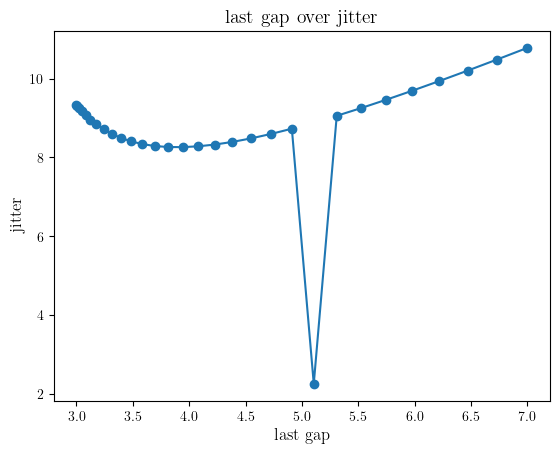

In [70]:
# plt.plot(foms["rateD"],foms["L first gap"],marker="o")
plt.plot(last_gap_list,foms["jitter"],marker="o")
plt.xlabel("last gap")
plt.ylabel("jitter")
# plt.ylim(0, 0.2)
# plt.xlim(0, 2)
plt.title("last gap over jitter")

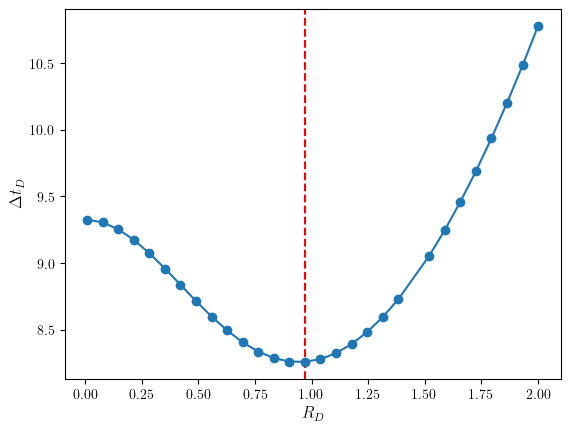

In [90]:
dat_list4 = foms


fig, ax = plt.subplots()
ax.set_xlabel("$R_D$")
ax.set_ylabel("$\Delta t_D$")

# ax.set_yscale('log')
# ax.set_xscale('log')

# Filter the data to only include pairs with first_gap_list values smaller than 1
filtered_indices = [i for i, gap in enumerate(first_gap_list) if (gap > -60 and gap < -1)]
filtered_first_gap_list = [first_gap_list[i] for i in filtered_indices]
filtered_efficiency = [dat_list4["efficiency"].values[i] for i in filtered_indices]

# plt.plot(filtered_first_gap_list, filtered_efficiency, marker="o")

# ax.set_ylim(0, 1)
# plt.plot(filtered_first_gap_list,
#        [dat_list4["efficiency"].values[i] for i in filtered_indices],
#       marker="o")

# plt.plot(first_gap_list,
#        dat_list4["jitter"].values,
#       marker="o")

condition=dat_list4["jitter"]<100
condition&=dat_list4["efficiency"]<1

dat_list4=dat_list4[condition]

min_jitter_rateD = dat_list4[dat_list4["jitter"]==dat_list4["jitter"].values.min()]["rateD"].values[0]
plt.axvline(x=min_jitter_rateD, color='r', linestyle='--', label=f'Min jitter at $R_D$={min_jitter_rateD:.2f}')

plt.plot(dat_list4["rateD"].values,
       dat_list4["jitter"].values,
      marker="o")

### Plots with varied parameters: TC, TV, RD, RM, g_sl,g_ml, eCfactor

#### Jitter over dark count rate

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


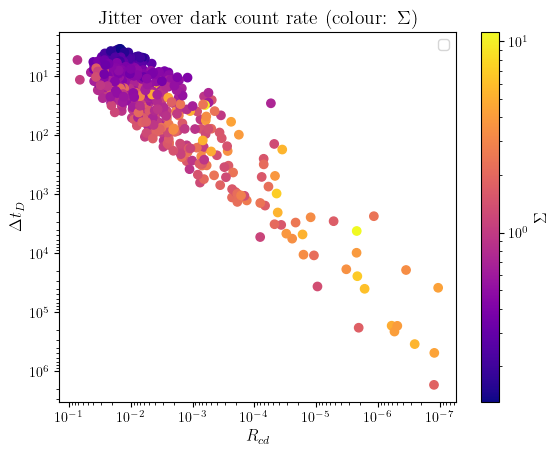

In [206]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v6")
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v5")])
dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.0
condition &= dset["efficiency"] <1


condition &= dset["entropy production"] >0.0



# condition &= dset["rateD"]>0.1
# condition &= dset["rateD"]<1

# condition &= dset["rateM"]>0.1
# condition &= dset["rateM"]<1

condition &= dset["g_sl"]<1
condition &= dset["g_sl"]>0.8

condition &= dset["g_ml"]<1
condition &= dset["g_ml"]>0.8


# condition &= dset["TC"]<1
# condition &= dset["TC"]<2

condition &= dset["dark count rate"]>10**-7



dset=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$R_{cd}$")
ax.set_ylabel("$\Delta t_D$")

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

ax.set_yscale('log')
ax.set_xscale('log')

# ax.set_ylim([0,1])

plt.title("Jitter over dark count rate (colour: $\Sigma$)")
scatter=plt.scatter(dset["dark count rate"].values,
                    dset["jitter"].values,
                    c=(dset["entropy production"].values),
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )

# for i in range(1,len(data)):
#     plt.plot(np.array(data[i]) [:-2,out_index("dark count rate")],np.array(data[i])[:-2,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")]))

# Plot linear function
# x = np.linspace(min(dset["dark count rate"]), max(dset["dark count rate"]), 100)
# y = 1/x**(1/1.1)  # Example linear function
# plt.plot(x, y, label='Eyballed function: $y =1/x^{1.1}$', color='blue',linestyle="--")

# Define the inverse function with an exponent
# def inverse_func(x, a, b):
#     return a / (x ** b)

# # Fit the data with increased maxfev
# popt, pcov = curve_fit(inverse_func, dset["dark count rate"].values, dset["jitter"].values,maxfev = 100)

# # Plot the fitted curve
# x_fit = np.linspace(min(dset["dark count rate"]), max(dset["dark count rate"]), 100)
# y_fit = inverse_func(x_fit, *popt)
# plt.plot(x_fit, y_fit, label=f'Fitted function: y = {popt[0]:.2f} / x^{popt[1]:.2f}', color='blue')

plt.colorbar(scatter, label="$\Sigma$")
plt.legend()

Restricting the dark count rate to be bigger than $10^{-7}$ shows us that there is no clear relation between jitter and dark count rate. I think its the jitter in general that we have to constrain to see relations of the other quantities, as arbitrary jitter will yield very long lasting non equilibrium dynamics enabling all kinds of stuff and is less interesting from an experimental point of view.

#### Efficiency over entropy production

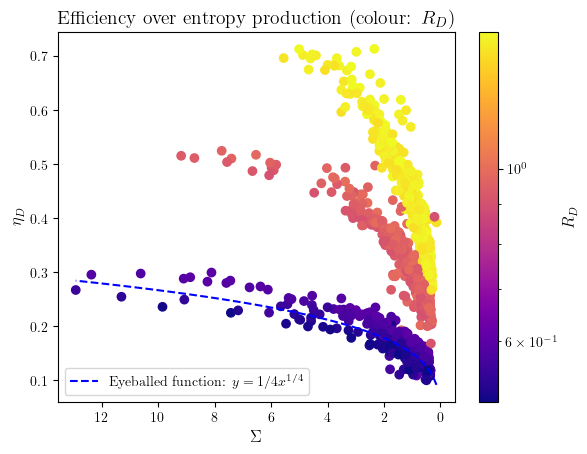

In [181]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.0
condition &= dset["efficiency"] <1

condition &= dset["entropy production"] >0.0



condition &= ((dset["rateD"]<0.6)& (dset["rateD"]>0.5))| ((dset["rateD"]<1)&( dset["rateD"]>0.9))| ((dset["rateD"]<1.5)&( dset["rateD"]>1.4))


rdval=2
dset=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma$")
ax.set_ylabel("$\eta_D$")

plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()

# ax.set_yscale('log')
# ax.set_xscale('log')

# ax.set_ylim([0,1])

plt.title("Efficiency over entropy production (colour: $R_D$)")
scatter=plt.scatter(dset["entropy production"].values,
                    dset["efficiency"].values,
                    c=(dset["rateD"].values),
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )


x = np.linspace(min(dset["entropy production"]), max(dset["entropy production"]), 100)
y = 0.15*x**(1/4)  # Example linear function
plt.plot(x, y, label='Eyeballed function: $y =1/4 x^{1/4}$', color='blue',linestyle="--")



plt.colorbar(scatter, label="$R_D$")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


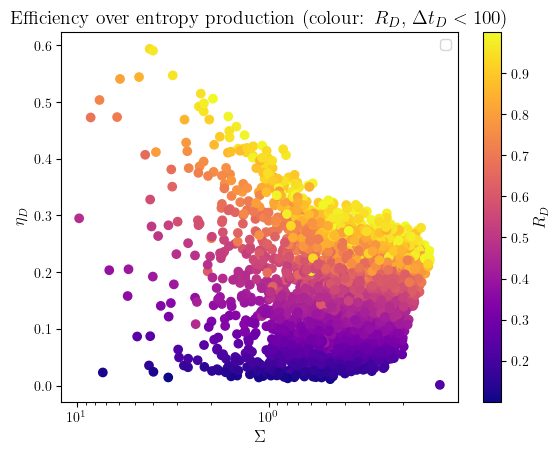

In [252]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v6")
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v5")])
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")])
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v3")])
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v2")])
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v1")])
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.0
condition &= dset["efficiency"] <1

# condition &= dset["entropy production"] <20
# condition &= dset["entropy production"] >0.0

condition &= dset["jitter"] <10**2

condition &= dset["rateD"] <1


dset=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma$")
ax.set_ylabel("$\eta_D$")

plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()

# ax.set_yscale('log')
ax.set_xscale('log')

# ax.set_ylim([0,1])

plt.title("Efficiency over entropy production (colour: $R_D$, $\Delta t_D<100$)")
scatter=plt.scatter(dset["entropy production"].values,
                    dset["efficiency"].values,
                    c=(dset["rateD"].values),
                    cmap='plasma',
                    norm=mcolor.Normalize() # .LogNorm() or Normalize
                )


plt.colorbar(scatter, label="$R_D$")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


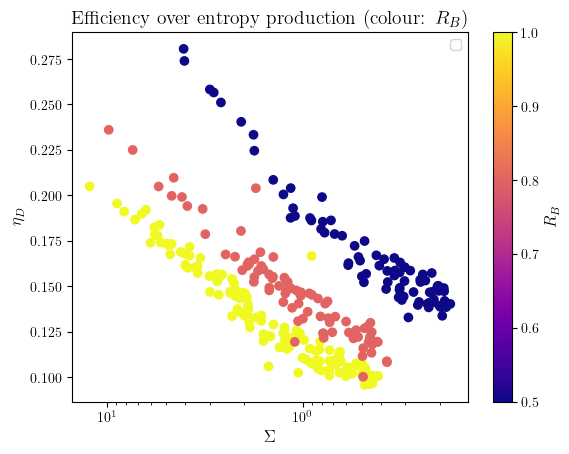

In [251]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v6")
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v5")])
dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")])
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v3")])
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v2")])
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v1")])
# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")])
condition = dset["k"] == 1
# condition &= dset["efficiency"] >0.0
# condition &= dset["efficiency"] <1

# condition &= dset["entropy production"] <20
# condition &= dset["entropy production"] >0.0

# condition &= dset["jitter"] <10**2

condition &= dset["rateD"] >0.5
condition &= dset["rateD"] <0.52


dset=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma$")
ax.set_ylabel("$\eta_D$")

plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()

# ax.set_yscale('log')
ax.set_xscale('log')

# ax.set_ylim([0,1])

plt.title("Efficiency over entropy production (colour: $R_B$)")
scatter=plt.scatter(dset["entropy production"].values,
                    dset["efficiency"].values,
                    c=(dset["rateB"].values),
                    cmap='plasma',
                    norm=mcolor.Normalize() # .LogNorm() or Normalize
                )


plt.colorbar(scatter, label="$R_B$")
plt.legend()

#### Jitter over entropy production

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


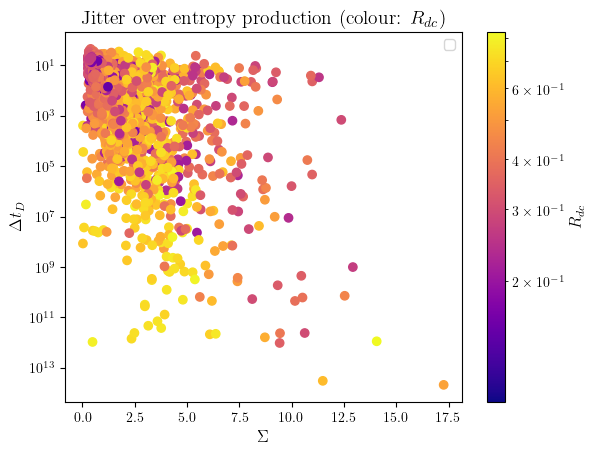

In [190]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.0
condition &= dset["efficiency"] <1
# condition &= dset["rateD"] >15
# condition &= dset["rateD"] <0.8
# condition &= dset["g_ml"] >10
# condition &= dset["g_ml"] <12

# condition &= dset["TC"] >0.6
# condition &= dset["TC"] <2
# condition &= dset["TV"] <-3
# condition &= dset["TV"] >-4
# condition &= dset["TH"] >dset["TC"]*(dset["e_l"]+dset["e_C"])/dset["e_C"]

# condition &= dset["TV"] < -5
# condition &= dset["g_ml"] <1

# condition &=  ((dset["jitter"] < 7) | ((dset["jitter"] < 10) & (dset["jitter"] > 9)) | ((dset["jitter"] < 15) & (dset["jitter"] > 14)))


# condition &= dset["entropy production"] >1
condition &= dset["entropy production"] >0.0

# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000



# condition &= ((dset["rateD"]<0.6)& (dset["rateD"]>0.5))| ((dset["rateD"]<1)&( dset["rateD"]>0.9))| ((dset["rateD"]<1.5)&( dset["rateD"]>1.4))
# condition &= dset["rateD"]>0.9

# condition &= dset["rateD"]<1.7
# condition &= dset["rateD"]>1.6

# condition &= dset["g_ml"]<2
# condition &= dset["g_ml"]>

# condition &= dset["jitter"]<10**10
# condition &= dset["jitter"]>9.8

# condition &= dset["rateM"]<0.9
# condition &= dset["dark count rate"]<10**(-4)

# condition &= dset["entropy production"]<1
# condition &= dset["entropy production"]>0.1

# condition &= dset["entropy rate"] >0
# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000

rdval=2
# condition &= dset["rateD"] >1.9
# condition &= ((dset["TC"]<0.3) & dset["TC"]>0.25)

dset=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma$")
ax.set_ylabel("$\Delta t_D$")

# plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

ax.set_yscale('log')
# ax.set_xscale('log')

# ax.set_ylim([0,1])

plt.title("Jitter over entropy production (colour: $R_{dc}$)")
scatter=plt.scatter(dset["entropy production"].values,
                    dset["jitter"].values,
                    c=(dset["efficiency"].values),
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )

# for i in range(1,len(data)):
#     plt.plot(np.array(data[i]) [:-2,out_index("dark count rate")],np.array(data[i])[:-2,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")]))

#Plot linear function
# x = np.linspace(min(dset["entropy production"]), max(dset["entropy production"]), 100)
# y = 0.15*x**(1/4)  # Example linear function
# plt.plot(x, y, label='Eyeballed function: $y =1/4 x^{1/4}$', color='blue',linestyle="--")

# Define the inverse function with an exponent a

# def inverse_func(x, a, b):
#     return a / (x ** b)

# # Fit the data with increased maxfev
# popt, pcov = curve_fit(inverse_func, dset["dark count rate"].values, dset["jitter"].values,maxfev = 100)

# # Plot the fitted curve
# x_fit = np.linspace(min(dset["dark count rate"]), max(dset["dark count rate"]), 100)
# y_fit = inverse_func(x_fit, *popt)
# plt.plot(x_fit, y_fit, label=f'Fitted function: y = {popt[0]:.2f} / x^{popt[1]:.2f}', color='blue')

plt.colorbar(scatter, label="$R_{dc}$")
plt.legend()

Does not really tell us much, seems like there is no clear link between entropy production and jitter, at least not without constraints

#### Dark count rate over entropy production

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


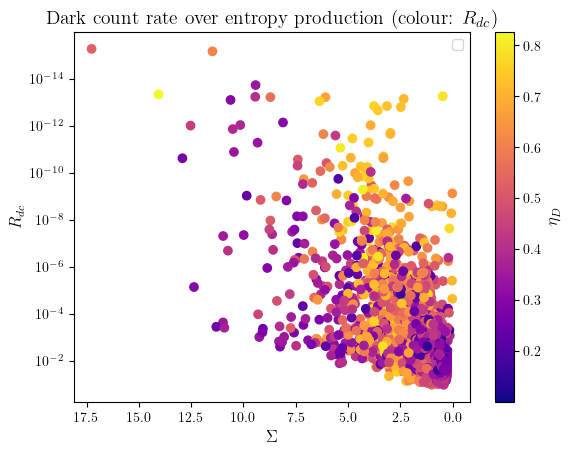

In [39]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.0
condition &= dset["efficiency"] <1
# condition &= dset["rateD"] >15
# condition &= dset["rateD"] <0.8
# condition &= dset["g_ml"] >10
# condition &= dset["g_ml"] <12

# condition &= dset["TC"] >0.6
# condition &= dset["TC"] <2
# condition &= dset["TV"] <-3
# condition &= dset["TV"] >-4
# condition &= dset["TH"] >dset["TC"]*(dset["e_l"]+dset["e_C"])/dset["e_C"]

# condition &= dset["TV"] < -5
# condition &= dset["g_ml"] <1

# condition &=  ((dset["jitter"] < 7) | ((dset["jitter"] < 10) & (dset["jitter"] > 9)) | ((dset["jitter"] < 15) & (dset["jitter"] > 14)))


# condition &= dset["entropy production"] >1
condition &= dset["entropy production"] >0.0

# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000



# condition &= ((dset["rateD"]<0.6)& (dset["rateD"]>0.5))| ((dset["rateD"]<1)&( dset["rateD"]>0.9))| ((dset["rateD"]<1.5)&( dset["rateD"]>1.4))
# condition &= dset["rateD"]>0.9

# condition &= dset["rateD"]<1.7
# condition &= dset["rateD"]>1.6

# condition &= dset["g_ml"]<2
# condition &= dset["g_ml"]>

# condition &= dset["jitter"]<10**10
# condition &= dset["jitter"]>9.8

# condition &= dset["rateM"]<0.9
# condition &= dset["dark count rate"]<10**(-4)

# condition &= dset["entropy production"]<1
# condition &= dset["entropy production"]>0.1

# condition &= dset["entropy rate"] >0
# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000

rdval=2
# condition &= dset["rateD"] >1.9
# condition &= ((dset["TC"]<0.3) & dset["TC"]>0.25)

# condition &= dset["efficiency"]>0.4
# condition &= dset["efficiency"]<0.5

dset=dset[condition]



fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma$")
ax.set_ylabel("$R_{dc}$")

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

ax.set_yscale('log')
# ax.set_xscale('log')

# ax.set_ylim([0,1])

plt.title("Dark count rate over entropy production (colour: $R_{dc}$)")
scatter=plt.scatter(dset["entropy production"].values,
                    dset["dark count rate"].values,
                    c=(dset["efficiency"].values),
                    cmap='plasma',
                    norm=mcolor.Normalize() # .LogNorm() or Normalize
                )

# for i in range(1,len(data)):
#     plt.plot(np.array(data[i]) [:-2,out_index("dark count rate")],np.array(data[i])[:-2,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")]))

#Plot linear function
# x = np.linspace(min(dset["entropy production"]), max(dset["entropy production"]), 100)
# y = 0.15*x**(1/4)  # Example linear function
# plt.plot(x, y, label='Eyeballed function: $y =1/4 x^{1/4}$', color='blue',linestyle="--")

# Define the inverse function with an exponent a

# def inverse_func(x, a, b):
#     return a / (x ** b)

# # Fit the data with increased maxfev
# popt, pcov = curve_fit(inverse_func, dset["dark count rate"].values, dset["jitter"].values,maxfev = 100)

# # Plot the fitted curve
# x_fit = np.linspace(min(dset["dark count rate"]), max(dset["dark count rate"]), 100)
# y_fit = inverse_func(x_fit, *popt)
# plt.plot(x_fit, y_fit, label=f'Fitted function: y = {popt[0]:.2f} / x^{popt[1]:.2f}', color='blue')

plt.colorbar(scatter, label="$\eta_D$")
plt.legend()

There does not seem to be any interesting relation there.

#### Efficiency over dark count rate

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


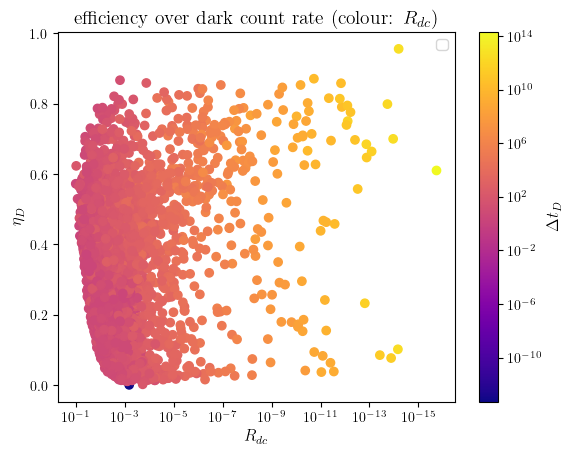

In [180]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v6")


# dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v5")
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v3")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v2")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v1")])
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.0
condition &= dset["efficiency"] <1
# condition &= dset["rateD"] >15
# condition &= dset["rateD"] <0.8
# condition &= dset["g_ml"] >10
# condition &= dset["g_ml"] <12

# condition &= dset["TC"] >0.7
# condition &= dset["TC"] <2
# condition &= dset["TV"] <-3
# condition &= dset["TV"] >-4
# condition &= dset["TH"] >dset["TC"]*(dset["e_l"]+dset["e_C"])/dset["e_C"]

# condition &= dset["TV"] < -5
# condition &= dset["g_ml"] <1

# condition &=  ((dset["jitter"] < 7) | ((dset["jitter"] < 10) & (dset["jitter"] > 9)) | ((dset["jitter"] < 15) & (dset["jitter"] > 14)))


# condition &= dset["entropy production"] >1
condition &= dset["entropy production"] >0.0

# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000



# condition &= ((dset["rateD"]<0.6)& (dset["rateD"]>0.5))| ((dset["rateD"]<1)&( dset["rateD"]>0.9))| ((dset["rateD"]<1.5)&( dset["rateD"]>1.4))
# condition &= dset["rateD"]>0.9

# condition &= dset["rateD"]<1.7
# condition &= dset["rateD"]>1.6

# condition &= dset["g_ml"]<2
# condition &= dset["g_ml"]>

# condition &= dset["jitter"]<10**10
# condition &= dset["jitter"]>9.8

# condition &= dset["rateM"]<0.9
# condition &= dset["dark count rate"]<10**(-4)

# condition &= dset["entropy production"]<1
# condition &= dset["entropy production"]>0.1

# condition &= dset["entropy rate"] >0
# condition &= np.log(dset["entropy production"]) < 0.75
# condition &= dset["entropy rate"] + dset["dark count rate"]<0.000

rdval=2
# condition &= dset["e_C_factor"] <1
# condition &= dset["rateM"] <1
# condition &= dset["rateD"] <1
# condition &= dset["g_ml"] <1
# condition &= dset["g_sl"] <1

# condition &= dset["entropy production"]>0.5
# condition &= dset["entropy production"]<0.51
# condition &= ((dset["TC"]<0.3) & dset["TC"]>0.25)

# condition &= dset["efficiency"]>0.4
# condition &= dset["efficiency"]<0.5
# condition &= dset["jitter"]<5
# condition &= dset["jitter"]<100
# condition &= dset["rateB"]==0.8

dset=dset[condition]




fig, ax = plt.subplots()
ax.set_xlabel("$R_{dc}$")
ax.set_ylabel("$\eta_D$")

plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()

# ax.set_yscale('log')
ax.set_xscale('log')

# ax.set_ylim([0,1])

plt.title("efficiency over dark count rate (colour: $R_{dc}$)")
scatter=plt.scatter(dset["dark count rate"].values,
                    dset["efficiency"].values,
                    c=(dset["jitter"]),
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )

# for i in range(1,len(data)):
#     plt.plot(np.array(data[i]) [:-2,out_index("dark count rate")],np.array(data[i])[:-2,out_index("efficiency")],label="TC="+str(np.array(data[i])[0,out_index("TC")]))

# # Plot linear function
# x = np.linspace(min(dset["rateD"]), max(dset["rateD"]), 100)
# y =  np.linspace(np.log(dset["rateB"].max()),np.log(dset["rateB"].max()),100) # Example linear function
# plt.plot(x, y, label='Eyeballed function: $y =1/4 x^{1/4}$', color='blue',linestyle="--")

# Define the inverse function with an exponent a

# def inverse_func(x, a, b):
#     return a / (x ** b)

# # Fit the data with increased maxfev
# popt, pcov = curve_fit(inverse_func, dset["dark count rate"].values, dset["jitter"].values,maxfev = 100)

# # Plot the fitted curve
# x_fit = np.linspace(min(dset["dark count rate"]), max(dset["dark count rate"]), 100)
# y_fit = inverse_func(x_fit, *popt)
# plt.plot(x_fit, y_fit, label=f'Fitted function: y = {popt[0]:.2f} / x^{popt[1]:.2f}', color='blue')

plt.colorbar(scatter, label="$\Delta t_D$")
plt.legend()

Not really interesting 

Since 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


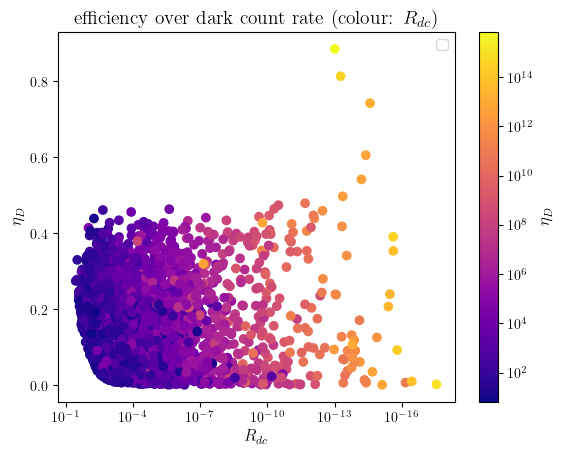

#### Efficiency over jitter

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


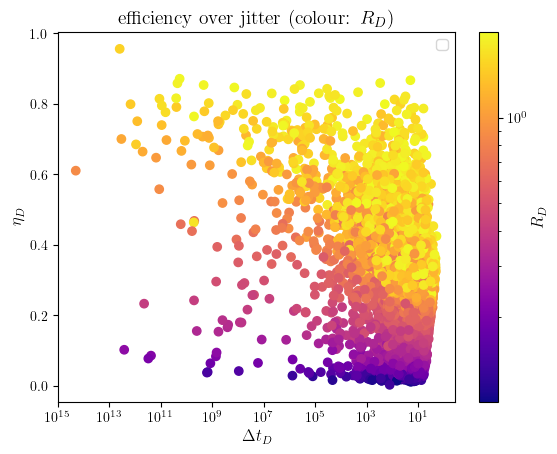

In [214]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v6")


# dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v5")
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v3")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v2")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v1")])
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.0
condition &= dset["efficiency"] <1
condition &= dset["entropy production"] >0.0

condition &= dset["jitter"]>0.01

dset=dset[condition]




fig, ax = plt.subplots()
ax.set_xlabel("$\Delta t_D$")
ax.set_ylabel("$\eta_D$")

plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()

# ax.set_yscale('log')
ax.set_xscale('log')

# ax.set_ylim([0,1])

Ladder_B_abs_rate=np.exp(-dset["e_s"].values/dset["TC"].values)*dset["rateB"].values
Ladder_D_abs_rate=np.exp(-(dset["e_s"].values+dset["e_l"].values)/dset["TC"].values)*dset["rateD"].values

plt.title("efficiency over jitter (colour: $R_D$)")
scatter=plt.scatter(dset["jitter"].values,
                    dset["efficiency"].values,
                    c=dset["rateD"].values,
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )



plt.colorbar(scatter, label="$R_D$")
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


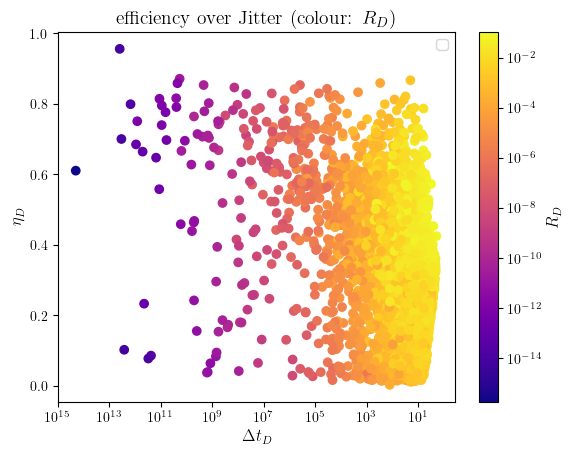

In [98]:
from scipy.optimize import curve_fit



dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v6")


# dset= pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v5")
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v4")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v3")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v2")])
# dset= pd.concat([dset,pd.read_csv("FOM_Dinv_exact_TC_TV_g_sl_rateD_eCfactor_rateM_v1")])
# dset= pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")
# dset= pd.read_csv("FOM_Dinv_exact_MaxTV_v1")

# dset= pd.concat([dset, pd.read_csv("FOM_Dinv_exact_TC_MaxTV_g_sl_rateD_eCfactor_rateM_v1")])
condition = dset["k"] == 1
condition &= dset["efficiency"] >0.0
condition &= dset["efficiency"] <1
condition &= dset["entropy production"] >0.0
# condition &= dset["entropy production"] <0.6

condition &= dset["jitter"]>0.01


# condition &= dset["rateD"]<0.5


dset=dset[condition]




fig, ax = plt.subplots()
ax.set_xlabel("$\Delta t_D$")
ax.set_ylabel("$\eta_D$")

plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()

# ax.set_yscale('log')
ax.set_xscale('log')

# ax.set_ylim([0,1])

Ladder_B_abs_rate=np.exp(-dset["e_s"].values/dset["TC"].values)*dset["rateB"].values
Ladder_D_abs_rate=np.exp(-(dset["e_s"].values+dset["e_l"].values)/dset["TC"].values)*dset["rateD"].values

plt.title("efficiency over Jitter (colour: $R_D$)")
scatter=plt.scatter(dset["jitter"].values,
                    dset["efficiency"].values,
                    c=dset["dark count rate"].values,
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )



plt.colorbar(scatter, label="$R_D$")
plt.legend()

There seems to be no interesting relation ship. RateD just increases the max efficiency and the jitter does nothing to all that. 

## Single parameter plots

### Varying TC for different TV

In [ ]:
plot_list=pd.DataFrame()
for TV in [-0.5,-1,-2,-5,-10]:
    parameters["TV"]=TV
    plot_list=pd.concat([plot_list,Parameter_plot(parameters,"TC",np.linspace(0.01,1,100))])

#### Efficiency over entropy production

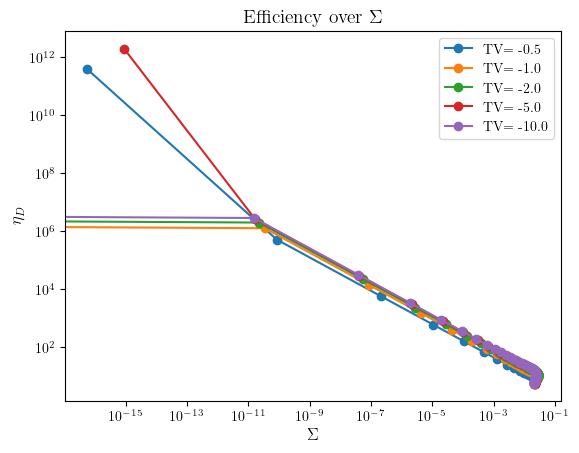

In [89]:
fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma$")
ax.set_ylabel("$\eta_D$")

ax.set_yscale('log')
ax.set_xscale('log')

# plt.gca().invert_xaxis()

[plt.plot(plot_list[plot_list["TV"]==TV]["dark count rate"].values,
          plot_list[plot_list["TV"]==TV]["jitter"].values,
          marker="o",
          label=f"TV= {plot_list[plot_list['TV']==TV]['TV'].values[0]}")
            for TV in [-0.5,-1,-2,-5,-10]]

plt.title("Efficiency over $\Sigma$")

plt.legend()

# caption = (
#   r"\textbf{Figure 1.} Parameters: \\"
#   fr"$R_M={parameters['rateM']}, R_B={parameters['rateB']}, R_D={parameters['rateD']}, T_H={parameters['TH']}, T_C={parameters['TC']}, T_B={parameters['Tb']}, T_D={parameters['Td']},$ \\"
#   r"\quad "
#   fr"$e_S={parameters['e_s']}, e_C={parameters['e_C']:.3f}, e_l={parameters['e_l']}, g_{{sl}}={parameters['g_sl']}, g_{{ml}}={parameters['g_ml']}, d_l={parameters['d_l']},$ \\"
#   fr"$t_f={parameters['t_f']}, t_{{\mathrm{{steps}}}}={parameters['t_steps']}, k={parameters['k']}$"
# )

# plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)